In [26]:
import pymc3 as pm
import theano
import theano.tensor as tt
#import pytensor.tensor as pt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
import exoplanet as xo
#from exoplanet.distributions import Angle

import pymc3_ext as pmx
from celerite2 import theano
import theano.tensor as tt

import astropy.units as u
from astropy import constants
from astropy.time import Time
#from matplotlib.patches import Ellipse


# conversion constant from au to R_sun
au_to_R_sun = (constants.au / constants.R_sun).value

# The position angle measurements come in degrees in the range [0, 360].
# We'll convert this to radians in the range [-pi, pi]
deg = np.pi / 180.0
rad_2_deg = 180 / np.pi
yr = 365.25

In [27]:
import math
from sigfig import round

def get_median_sigma(pos):
    """
    Helper function to estimate median and sigma from posterior distribution
    Args:
        pos: array from posterior distribution
    Returns:
        (median,sigma): best fit value and 1 sigma uncertainty
    """
    temp = np.percentile(pos,[16,50,84])
    lower = temp[1]-temp[0]
    upper = temp[2]-temp[1]
    sigma = np.max([lower,upper])
    
    return (temp[1], sigma)

def fmt(val, sig):
    """
    Format val±sig with the uncertainty rounded to 2 significant figures
    and the central value matched to the same precision.
    Uses numpy rounding + f-strings (sigfig.round cannot preserve 2-sf uncertainty).
    """
    mag = math.floor(math.log10(abs(sig)))
    ndecimals = max(0, 1 - mag)      # decimal places needed for 2 sig figs
    factor = 10 ** (mag - 1)
    sig_r = np.round(sig / factor) * factor
    val_r = np.round(val / factor) * factor
    if ndecimals > 0:
        return f'{val_r:.{ndecimals}f}$\\pm${sig_r:.{ndecimals}f}'
    else:
        return f'{val_r:.0f}$\\pm${sig_r:.0f}'

Median MJD TO95 48635.456400000025
Median JD FEROS 54310.466950000264
Median JD FEROS2 57061.77270000009
Median MJD CTIO 59411.9949
Median MJD ELODIE 50841.6274195
Median MJD Mercator 57054.6979
Median MJD HARPS 60107.96299450006
Median MJD NIRPS 60107.96299450006


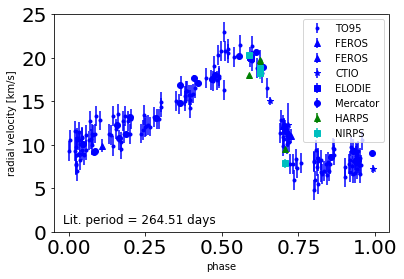

In [28]:
# Read Torres et al. 1995 RV data
RV_Aa = pd.read_csv('RV_Aa.csv')

t = RV_Aa['HJD'].to_numpy()
rva = RV_Aa['Aa'].to_numpy()
rva_err = RV_Aa['Aa_err'].to_numpy()

print("Median MJD TO95", np.median(t)- 2400000.5)

# Read FEROS RV data
RV_Aa = pd.read_csv('RV_Aa_FEROS.csv')

t_FEROS = RV_Aa['MJD'].to_numpy()

t_FEROS = t_FEROS  + 2400000.0 # MJD to JD
print("Median JD FEROS", (np.median(t_FEROS)- 2400000.5))
rva_FEROS = RV_Aa['Aa'].to_numpy()
rva_err_FEROS = RV_Aa['Aa_err'].to_numpy()

# Read FEROS RV data
RV_Aa = pd.read_csv('RV_Aa_FEROS2.csv')

t_FEROS2 = RV_Aa['MJD'].to_numpy()
t_FEROS2 = t_FEROS2  + 2400000.0 # MJD to JD
print("Median JD FEROS2", (np.median(t_FEROS2)- 2400000.5))
rva_FEROS2 = RV_Aa['Aa'].to_numpy()
rva_err_FEROS2 = RV_Aa['Aa_err'].to_numpy()


# Read CHIRON RV data
RV_Aa = pd.read_csv('RV_Aa_CTIO.csv')

t_CTIO = RV_Aa['MJD'].to_numpy()
print("Median MJD CTIO", np.median(t_CTIO))
t_CTIO = t_CTIO  + 2400000.5 # MJD to JD
rva_CTIO = RV_Aa['Aa'].to_numpy()
rva_err_CTIO = RV_Aa['Aa_err'].to_numpy()

# Read ELODIE RV data
RV_Aa = pd.read_csv('RV_Aa_ELODIE.csv')

t_ELODIE = RV_Aa['MJD'].to_numpy()
print("Median MJD ELODIE", np.median(t_ELODIE))
t_ELODIE = t_ELODIE  + 2400000.5 # MJD to JD
rva_ELODIE = RV_Aa['Aa'].to_numpy()
rva_err_ELODIE = RV_Aa['Aa_err'].to_numpy()

# Read Mercator RV data
RV_Aa = pd.read_csv('RV_Aa_Mercator.csv')

t_Mercator = RV_Aa['MJD'].to_numpy()
print("Median MJD Mercator", np.median(t_Mercator))
t_Mercator = t_Mercator  + 2400000.5 # MJD to JD
rva_Mercator = RV_Aa['Aa'].to_numpy()
rva_err_Mercator = RV_Aa['Aa_err'].to_numpy()

# Read HARPS RV data (Aa)
RV_Aa = pd.read_csv('RV_Aa_HARPS.csv')
t_HARPS = RV_Aa['MJD'].to_numpy() + 2400000.5  # MJD to JD
print("Median MJD HARPS", np.median(t_HARPS) - 2400000.5)
rva_HARPS = RV_Aa['Aa'].to_numpy()
rva_err_HARPS = RV_Aa['Aa_err'].to_numpy()

# Read NIRPS RV data (Aa)
RV_Aa = pd.read_csv('RV_Aa_NIRPS.csv')
t_NIRPS = RV_Aa['MJD'].to_numpy() + 2400000.5  # MJD to JD
print("Median MJD NIRPS", np.median(t_NIRPS) - 2400000.5)
rva_NIRPS = RV_Aa['Aa'].to_numpy()
rva_err_NIRPS = RV_Aa['Aa_err'].to_numpy()


# Plot the observations "folded" on the published period:
# Torres et al. 1995
#lit_period = 262.15
# Zuniga-Fernandez et al. 2021
lit_period = 264.51

# Primary
plt.errorbar(
    (t % lit_period) / lit_period, rva, yerr=rva_err, fmt=".b", capsize=0, label="TO95"
)

plt.errorbar(
    (t_FEROS % lit_period) / lit_period, rva_FEROS, yerr=rva_err_FEROS, fmt="^b", capsize=0, label="FEROS"
)

plt.errorbar(
    (t_FEROS2 % lit_period) / lit_period, rva_FEROS2, yerr=rva_err_FEROS2, fmt="^b", capsize=0, label="FEROS"
)

plt.errorbar(
    (t_CTIO % lit_period) / lit_period, rva_CTIO, yerr=rva_err_CTIO, fmt="*b", capsize=0, label="CTIO"
)

plt.errorbar(
    (t_ELODIE % lit_period) / lit_period, rva_ELODIE, yerr=rva_err_ELODIE, fmt="sb", capsize=0, label="ELODIE"
)

plt.errorbar(
    (t_Mercator % lit_period) / lit_period, rva_Mercator, yerr=rva_err_Mercator, fmt="ob", capsize=0, label="Mercator"
)

plt.errorbar(
    (t_HARPS % lit_period) / lit_period, rva_HARPS, yerr=rva_err_HARPS, fmt="^g", capsize=0, label="HARPS"
)

plt.errorbar(
    (t_NIRPS % lit_period) / lit_period, rva_NIRPS, yerr=rva_err_NIRPS, fmt="sc", capsize=0, label="NIRPS"
)

# Secondary (Ab)
#plt.errorbar(
#    (t_HARPSAb % lit_period) / lit_period, rvb_HARPS, yerr=rvb_err_HARPS, fmt="^r", capsize=0, label="HARPS Ab"
#)

#plt.errorbar(
#    (t_NIRPSAb % lit_period) / lit_period, rvb_NIRPS, yerr=rvb_err_NIRPS, fmt="sm", capsize=0, label="NIRPS Ab"
#)

#plt.xlim(0, 1)
plt.ylim(0, 25)
plt.annotate(
    "Lit. period = {0:.2f} days".format(lit_period),
    xy=(0.5, 0),
    xycoords="axes fraction",
    xytext=(-5, 5),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=12,
)

plt.legend(loc='upper right', prop={'size': 10})

plt.ylabel("radial velocity [km/s]")
_ = plt.xlabel("phase")


In [30]:
#Define the model to fit SB2 (primary Aa + secondary Ab from HARPS/NIRPS)

with pm.Model() as model:

    # Parameters initial values from Torres et al. 1995
    logK1 = pm.Uniform(
        "logK1",
        lower=np.log(4),
        upper=np.log(20),
        testval=np.log(6.81),
    )

    # K2 semi-amplitude
    #logK2 = pm.Uniform(
    #    "logK2",
    #    lower=np.log(10),
    #    upper=np.log(60),
    #    testval=np.log(25.0),
    #)

    logP = pm.Uniform(
        "logP", lower=np.log(200), upper=np.log(300), testval=np.log(264.51)
    )
    
    P = pm.Deterministic("P", tt.exp(logP))
    #Primary
    K1 = pm.Deterministic("K1", tt.exp(logK1))
    # Secondary
    #K2 = pm.Deterministic("K2", tt.exp(logK2))
    
    tp_0 = 48742.5 + 2400000.5 # [Julian Date]
    tp = pm.Normal("tp", mu=tp_0, sd=10, testval=tp_0)
   
    # Parameterize the eccentricity using:
    #  h = sqrt(e) * cos(w)
    #  k = sqrt(e) * sin(w)
    # testval from Torres et al. 1995 (e ~ 0.484 and omega ~ 64.4 deg)
    hk = pmx.UnitDisk("hk", testval=np.array([-0.29, 0.83]))
    ecc = pm.Deterministic("e", hk[0] ** 2 + hk[1] ** 2)
    omega = pm.Deterministic("w", tt.arctan2(hk[1], hk[0]))
    
    orbit = xo.orbits.KeplerianOrbit(
        period=P, t_periastron=tp, ecc=ecc, omega=omega
    )

    # System velocities per instrument
    gamma = pm.Uniform("gamma", lower=0, upper=20, testval=12)
    gamma_FEROS = pm.Uniform("gamma_FEROS", lower=0, upper=20, testval=14)
    gamma_FEROS2 = pm.Uniform("gamma_FEROS2", lower=0, upper=20, testval=14)
    gamma_CTIO = pm.Uniform("gamma_CTIO", lower=0, upper=30, testval=10)
    gamma_ELODIE = pm.Uniform("gamma_ELODIE", lower=0, upper=30, testval=10)
    gamma_Mercator = pm.Uniform("gamma_Mercator", lower=0, upper=30, testval=10)
    gamma_HARPS = pm.Uniform("gamma_HARPS", lower=0, upper=50, testval=12)
    gamma_NIRPS = pm.Uniform("gamma_NIRPS", lower=0, upper=50, testval=12)

    # Jitter parameters (primary only for SB1 instruments; A/B for SB2 instruments)
    logjit_TO95 = pm.Uniform("logjitterTO95", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
    logjit_FEROS = pm.Uniform("logjitterFEROS", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
    logjit_FEROS2 = pm.Uniform("logjitterFEROS2", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
    logjit_CTIO = pm.Uniform("logjitterCTIO", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
    logjit_ELODIE = pm.Uniform("logjitterELODIE", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
    logjit_Mercator = pm.Uniform("logjitterMercator", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
    logjit_HARPS_A = pm.Uniform("logjitterHARPS_A", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
    #logjit_HARPS_B = pm.Uniform("logjitterHARPS_B", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
    logjit_NIRPS_A = pm.Uniform("logjitterNIRPS_A", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
    #logjit_NIRPS_B = pm.Uniform("logjitterNIRPS_B", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
    
    jit_TO95 = pm.Deterministic("jitTO95", tt.exp(logjit_TO95))
    jit_FEROS = pm.Deterministic("jitFEROS", tt.exp(logjit_FEROS))
    jit_FEROS2 = pm.Deterministic("jitFEROS2", tt.exp(logjit_FEROS2))
    jit_CTIO = pm.Deterministic("jitCTIO", tt.exp(logjit_CTIO))
    jit_ELODIE = pm.Deterministic("jitELODIE", tt.exp(logjit_ELODIE))
    jit_Mercator = pm.Deterministic("jitMercator", tt.exp(logjit_Mercator))
    jit_HARPS_A = pm.Deterministic("jitHARPS_A", tt.exp(logjit_HARPS_A))
    #jit_HARPS_B = pm.Deterministic("jitHARPS_B", tt.exp(logjit_HARPS_B))
    jit_NIRPS_A = pm.Deterministic("jitNIRPS_A", tt.exp(logjit_NIRPS_A))
    #jit_NIRPS_B = pm.Deterministic("jitNIRPS_B", tt.exp(logjit_NIRPS_B))

    # get the total errors
    def get_err(rv_err, logjitter):
        return tt.sqrt(rv_err**2 + tt.exp(2*logjitter))

    # Set up the radial velocity model
    def model_rv1(jd, offset):
        return offset + orbit.get_radial_velocity(jd, K=K1)

    def model_rv2(jd, offset):
        return offset - orbit.get_radial_velocity(jd, K=K2)

    # Primary (Aa)
    rvmodel_a = pm.Deterministic("rvmodel_a", model_rv1(t, gamma))
    rvmodel_a_FEROS = pm.Deterministic("rvmodel_a_FEROS", model_rv1(t_FEROS, gamma_FEROS))
    rvmodel_a_FEROS2 = pm.Deterministic("rvmodel_a_FEROS2", model_rv1(t_FEROS2, gamma_FEROS2))
    rvmodel_a_CTIO = pm.Deterministic("rvmodel_a_CTIO", model_rv1(t_CTIO, gamma_CTIO))
    rvmodel_a_ELODIE = pm.Deterministic("rvmodel_a_ELODIE", model_rv1(t_ELODIE, gamma_ELODIE))
    rvmodel_a_Mercator = pm.Deterministic("rvmodel_a_Mercator", model_rv1(t_Mercator, gamma_Mercator))
    rvmodel_a_HARPS = pm.Deterministic("rvmodel_a_HARPS", model_rv1(t_HARPS, gamma_HARPS))
    rvmodel_a_NIRPS = pm.Deterministic("rvmodel_a_NIRPS", model_rv1(t_NIRPS, gamma_NIRPS))

    # Secondary (Ab) — only HARPS and NIRPS have Ab measurements
    #rvmodel_b_HARPS = pm.Deterministic("rvmodel_b_HARPS", model_rv2(t_HARPSAb, gamma_HARPS))
    #rvmodel_b_NIRPS = pm.Deterministic("rvmodel_b_NIRPS", model_rv2(t_NIRPSAb, gamma_NIRPS))

    # Condition on the observations — Primary
    pm.Normal("obs_a", mu=rvmodel_a, sd=get_err(rva_err, logjit_TO95), observed=rva)
    pm.Normal("obs_a_FEROS", mu=rvmodel_a_FEROS, sd=get_err(rva_err_FEROS, logjit_FEROS), observed=rva_FEROS)
    pm.Normal("obs_a_FEROS2", mu=rvmodel_a_FEROS2, sd=get_err(rva_err_FEROS2, logjit_FEROS2), observed=rva_FEROS2)
    pm.Normal("obs_a_CTIO", mu=rvmodel_a_CTIO, sd=get_err(rva_err_CTIO, logjit_CTIO), observed=rva_CTIO)
    pm.Normal("obs_a_ELODIE", mu=rvmodel_a_ELODIE, sd=get_err(rva_err_ELODIE, logjit_ELODIE), observed=rva_ELODIE)
    pm.Normal("obs_a_Mercator", mu=rvmodel_a_Mercator, sd=get_err(rva_err_Mercator, logjit_Mercator), observed=rva_Mercator)
    pm.Normal("obs_a_HARPS", mu=rvmodel_a_HARPS, sd=get_err(rva_err_HARPS, logjit_HARPS_A), observed=rva_HARPS)
    pm.Normal("obs_a_NIRPS", mu=rvmodel_a_NIRPS, sd=get_err(rva_err_NIRPS, logjit_NIRPS_A), observed=rva_NIRPS)

    # Condition on the observations — Secondary (Ab)
    #pm.Normal("obs_b_HARPS", mu=rvmodel_b_HARPS, sd=get_err(rvb_err_HARPS, logjit_HARPS_B), observed=rvb_HARPS)
    #pm.Normal("obs_b_NIRPS", mu=rvmodel_b_NIRPS, sd=get_err(rvb_err_NIRPS, logjit_NIRPS_B), observed=rvb_NIRPS)

    # Optimize the logp
    map_soln = model.test_point
    map_soln = pmx.optimize(map_soln, [gamma, gamma_FEROS, gamma_FEROS2, gamma_CTIO, gamma_ELODIE,
                                       gamma_HARPS, gamma_NIRPS, logK1])
    map_soln = pmx.optimize(map_soln)


optimizing logp for variables: [logK1, gamma_NIRPS, gamma_HARPS, gamma_ELODIE, gamma_CTIO, gamma_FEROS2, gamma_FEROS, gamma]


message: Optimization terminated successfully.
logp: -783.5454176048507 -> -664.7091037161149
optimizing logp for variables: [logjitterNIRPS_A, logjitterHARPS_A, logjitterMercator, logjitterELODIE, logjitterCTIO, logjitterFEROS2, logjitterFEROS, logjitterTO95, gamma_NIRPS, gamma_HARPS, gamma_Mercator, gamma_ELODIE, gamma_CTIO, gamma_FEROS2, gamma_FEROS, gamma, hk, tp, logP, logK1]


message: Optimization terminated successfully.
logp: -664.7091037161149 -> -322.5391442737405


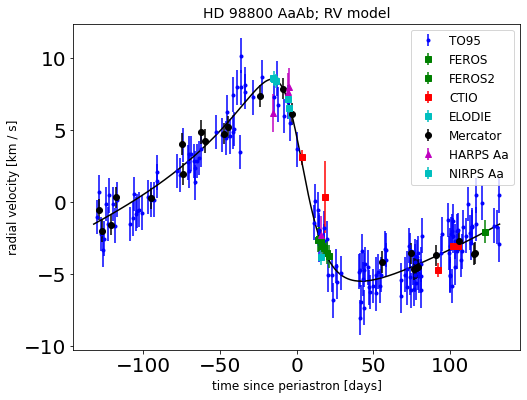

In [31]:
period = map_soln["P"]
tp = map_soln["tp"]
gamma = map_soln["gamma"]
gamma_FEROS = map_soln["gamma_FEROS"]
gamma_FEROS2 = map_soln["gamma_FEROS2"]
gamma_CTIO = map_soln["gamma_CTIO"]
gamma_ELODIE = map_soln["gamma_ELODIE"]
gamma_Mercator = map_soln["gamma_Mercator"]
gamma_HARPS = map_soln["gamma_HARPS"]
gamma_NIRPS = map_soln["gamma_NIRPS"]

fig, axes = plt.subplots(figsize=(8, 6))

ELO_errA = np.sqrt(rva_err_ELODIE**2 + np.exp(2 * np.median(map_soln["logjitterELODIE"])))

TO95_errA = np.sqrt(rva_err**2 + np.exp(2 * np.median(map_soln["logjitterTO95"])))

CTIO_errA = np.sqrt(rva_err_CTIO**2 + np.exp(2 * np.median(map_soln["logjitterCTIO"])))

FEROS_errA = np.sqrt(rva_err_FEROS**2 + np.exp(2 * np.median(map_soln["logjitterFEROS"])))

FEROS2_errA = np.sqrt(rva_err_FEROS2**2 + np.exp(2 * np.median(map_soln["logjitterFEROS2"])))

Mercator_errA = np.sqrt(rva_err_Mercator**2 + np.exp(2 * np.median(map_soln["logjitterMercator"])))

HARPS_errA = np.sqrt(rva_err_HARPS**2 + np.exp(2 * np.median(map_soln["logjitterHARPS_A"])))
#HARPS_errB = np.sqrt(rvb_err_HARPS**2 + np.exp(2 * np.median(map_soln["logjitterHARPS_B"])))

NIRPS_errA = np.sqrt(rva_err_NIRPS**2 + np.exp(2 * np.median(map_soln["logjitterNIRPS_A"])))
#NIRPS_errB = np.sqrt(rvb_err_NIRPS**2 + np.exp(2 * np.median(map_soln["logjitterNIRPS_B"])))

#print(ELO_errA)

#print(FEROS_errA)

#print(FEROS2_errA)

#print(CTIO_errA)

#print(np.median(TO95_errA))

    
#xx = [-0.5 * period, 0.5 * period]
#yy = [gamma, gamma]

#plt.plot(xx,yy,'--',c='k',alpha = 0.8)

folded = ((t - tp + 0.5 * period) % period) - 0.5 * period
folded_F = ((t_FEROS - tp + 0.5 * period) % period) - 0.5 * period
folded_F2 = ((t_FEROS2 - tp + 0.5 * period) % period) - 0.5 * period
folded_C = ((t_CTIO - tp + 0.5 * period) % period) - 0.5 * period
folded_E = ((t_ELODIE - tp + 0.5 * period) % period) - 0.5 * period
folded_M = ((t_Mercator - tp + 0.5 * period) % period) - 0.5 * period
folded_H = ((t_HARPS - tp + 0.5 * period) % period) - 0.5 * period
folded_N = ((t_NIRPS - tp + 0.5 * period) % period) - 0.5 * period
#folded_HAb = ((t_HARPSAb - tp + 0.5 * period) % period) - 0.5 * period
#folded_NAb = ((t_NIRPSAb - tp + 0.5 * period) % period) - 0.5 * period

plt.errorbar(folded, rva-gamma, yerr=TO95_errA, fmt=".b", label="TO95")
plt.errorbar(folded_F, rva_FEROS-gamma_FEROS, yerr=FEROS_errA, fmt="sg", label="FEROS")
plt.errorbar(folded_F2, rva_FEROS2-gamma_FEROS2, yerr=FEROS2_errA, fmt="sg", label="FEROS2")
plt.errorbar(folded_C, rva_CTIO-gamma_CTIO, yerr=CTIO_errA, fmt="sr", label="CTIO")
plt.errorbar(folded_E, rva_ELODIE-gamma_ELODIE, yerr=ELO_errA, fmt="sc", label="ELODIE")
plt.errorbar(folded_M, rva_Mercator-gamma_Mercator, yerr=Mercator_errA, fmt="ok", label="Mercator")
plt.errorbar(folded_H, rva_HARPS-gamma_HARPS, yerr=HARPS_errA, fmt="^m", label="HARPS Aa")
plt.errorbar(folded_N, rva_NIRPS-gamma_NIRPS, yerr=NIRPS_errA, fmt="sc", label="NIRPS Aa")
#plt.errorbar(folded_HAb, rvb_HARPS-gamma_HARPS, yerr=HARPS_errB, fmt="^r", label="HARPS Ab")
#plt.errorbar(folded_NAb, rvb_NIRPS-gamma_NIRPS, yerr=NIRPS_errB, fmt="Dm", label="NIRPS Ab")

x_phase = np.linspace(-0.5 * period, 0.5 * period, 500)

with model:
    y1_mod = pmx.eval_in_model(model_rv1(x_phase + tp, gamma), map_soln)

#print(period)
plt.plot(x_phase, y1_mod-gamma, "k")

plt.legend(fontsize=12)
plt.ylabel("radial velocity [km / s]", fontsize=12)
plt.xlabel("time since periastron [days]", fontsize=12)
_ = plt.title("HD 98800 AaAb; RV model", fontsize=14)


In [32]:
#That looks fine, so now we can run the MCMC sampler:
np.random.seed(39091)
with model:
    trace = pmx.sample(
        tune=1500, draws=1000, start=map_soln, chains=4, cores=4, target_accept=0.95
    )

/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/pymc3_ext/sampling/sampling.py:109: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return pm.sample(draws=draws, tune=tune, model=model, step=step, **kwargs)
Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc3:Multiprocess sampling (4 chains in 4 jobs)
NUTS: [logjitterNIRPS_A, logjitterHARPS_A, logjitterMercator, logjitterELODIE, logjitterCTIO, logjitterFEROS2, logjitterFEROS, logjitterTO95, gamma_NIRPS, gamma_HARPS, gamma_Mercator, gamma_ELODIE, gamma_CTIO, gamma_FEROS2, gamma_FEROS, gamma, hk, tp, logP, logK1]
INFO:pymc3:NUTS: [logjitterNIRPS_A, logjitterHARPS_A, logjitterMercator, logjitterELODIE, logjitterCTIO, logjitterFEROS2, logjitterFEROS, logjitterTO95, gamma_NIRPS, gamma_HARPS, gamma_Mercator, gamma_ELODIE, gamma_CTIO, 

/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 109 seconds.
INFO:pymc3:Sampling 4 chains for 1_500 tune and 1_000 draw iterations (

In [33]:
with model:
    summary = pm.summary(
        trace,
        var_names=["K1", "P", "e", "w", "gamma", "tp"],
        round_to = 4
    )
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
K1,6.878100e+00,0.1813,6.529300e+00,7.200300e+00,0.0039,0.0027,2156.9175,2469.2177,1.0016
P,2.645217e+02,0.0365,2.644562e+02,2.645930e+02,0.0007,0.0005,2592.3994,2616.9712,1.0019
e,4.855000e-01,0.0164,4.533000e-01,5.151000e-01,0.0004,0.0003,2215.5382,2803.1263,1.0028
w,1.126800e+00,0.0531,1.032200e+00,1.229700e+00,0.0008,0.0005,4707.9584,2988.5516,1.0013
gamma,1.282290e+01,0.0988,1.264470e+01,1.300990e+01,0.0014,0.0010,4654.6427,2877.3808,1.0013
tp,2.448740e+06,1.7372,2.448737e+06,2.448743e+06,0.0241,0.0170,5197.4606,2844.0994,1.0016


Period (days): 264.521$\pm$0.036
Tp (MJD): 48739.6$\pm$1.7
omega (deg): 64.6$\pm$3.1
e: 0.486$\pm$0.017
K1 (km/s): 6.88$\pm$0.19
gamma TO95 (km/s): 12.82$\pm$0.10
gamma FEROS (km/s): 14.59$\pm$0.43
gamma FEROS 2 (km/s): 12.0$\pm$1.2
gamma CTIO (km/s): 11.94$\pm$0.21
gamma ELODIE (km/s): 11.80$\pm$0.56
gamma Mercator (km/s): 12.86$\pm$0.17
gamma HARPS (km/s): 11.79$\pm$0.99
gamma NIRPS (km/s): 11.59$\pm$0.57


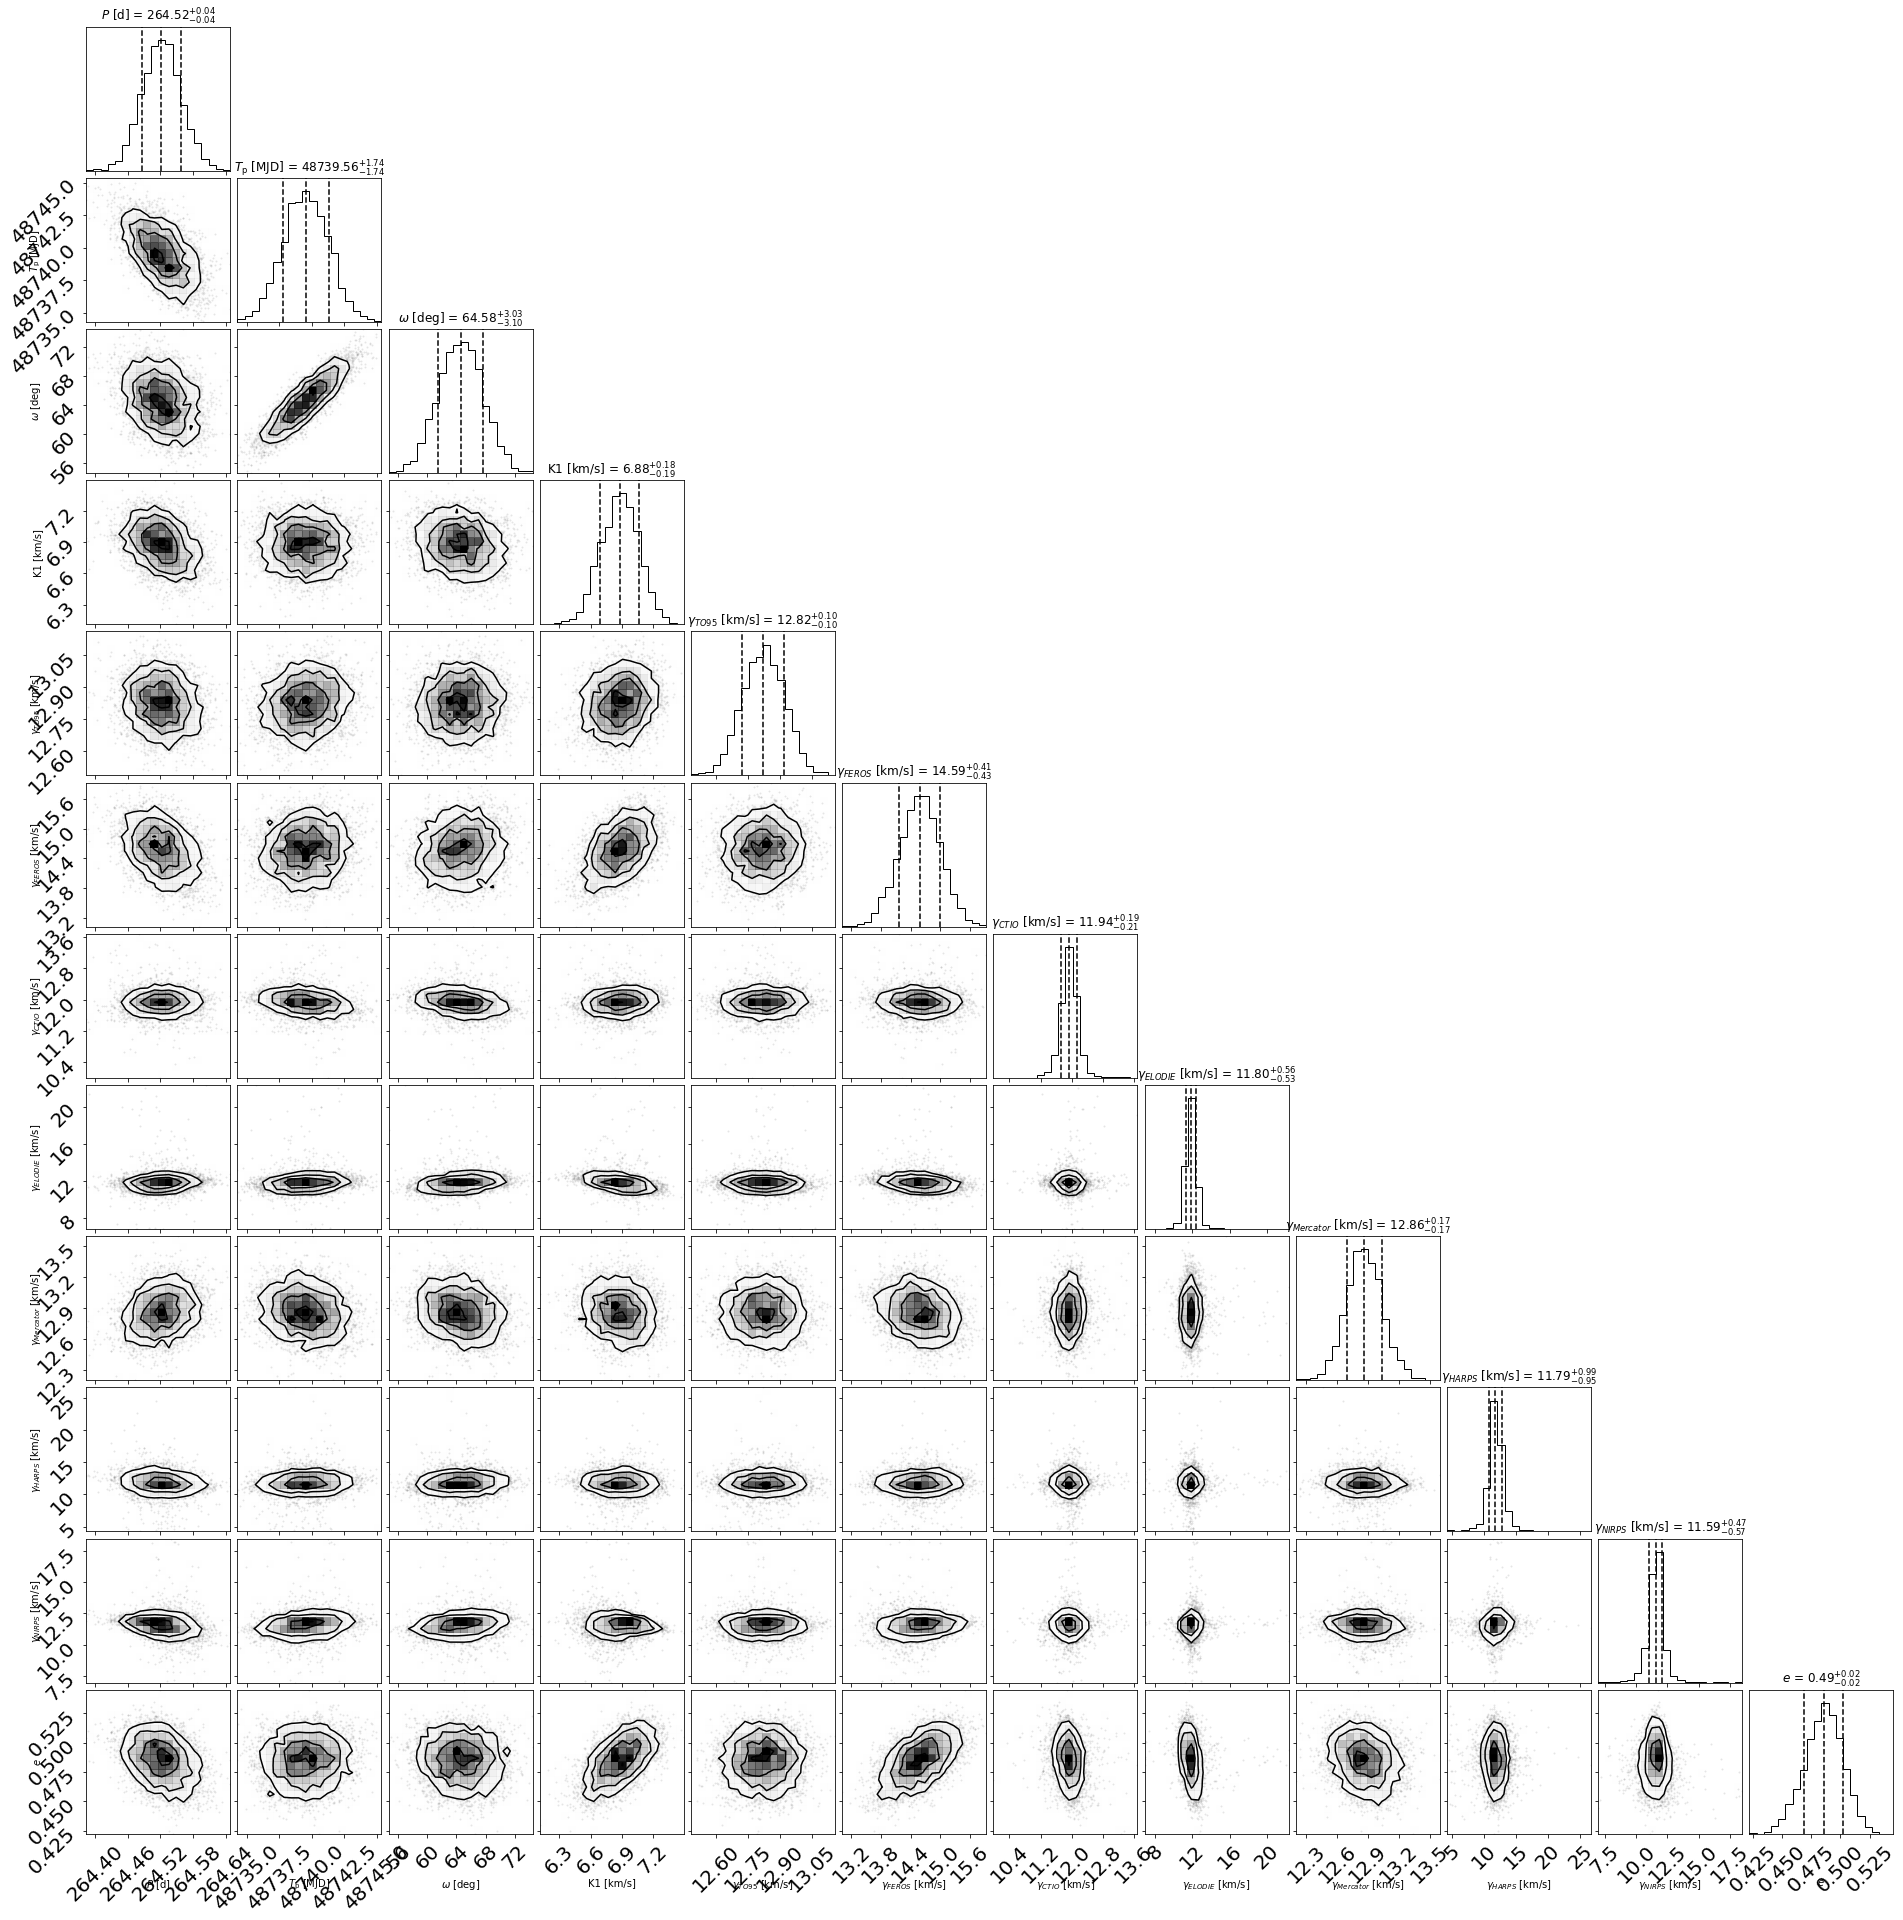

In [34]:
samples = pm.trace_to_dataframe(trace, varnames=["e"])
samples["$P$ [d]"] = trace["P"]
samples["$T_\mathrm{p}$ [MJD]"] = trace["tp"] - 2400000.5
samples["$\omega$ [deg]"] = (trace["w"] * rad_2_deg) % 360
samples["K1 [km/s]"] = (trace["K1"])
#samples["K2 [km/s]"] = (trace["K2"])
samples["$\gamma_{TO95}$ [km/s]"] = (trace["gamma"])
samples["$\gamma_{FEROS}$ [km/s]"] = (trace["gamma_FEROS"])
samples["$\gamma_{CTIO}$ [km/s]"] = (trace["gamma_CTIO"])
samples["$\gamma_{ELODIE}$ [km/s]"] = (trace["gamma_ELODIE"])
samples["$\gamma_{Mercator}$ [km/s]"] = (trace["gamma_Mercator"])
samples["$\gamma_{HARPS}$ [km/s]"] = (trace["gamma_HARPS"])
samples["$\gamma_{NIRPS}$ [km/s]"] = (trace["gamma_NIRPS"])
samples["$e$"] = samples["e"]

period, period_s = get_median_sigma(trace["P"])
print("Period (days): "+fmt(period, period_s))

tp, tp_s = get_median_sigma(trace["tp"]- 2400000.5)
print("Tp (MJD): "+fmt(tp, tp_s))

omega, omega_s = get_median_sigma((trace["w"] * rad_2_deg) % 360)
print("omega (deg): "+fmt(omega, omega_s))

ecc, ecc_s = get_median_sigma(trace["e"])
print("e: "+fmt(ecc, ecc_s))

K1, K1_s = get_median_sigma(trace["K1"])
print("K1 (km/s): "+fmt(K1, K1_s))

#K2, K2_s = get_median_sigma(trace["K2"])
#print("K2 (km/s): "+fmt(K2, K2_s))

gamma, gamma_s = get_median_sigma(trace["gamma"])
print("gamma TO95 (km/s): "+fmt(gamma, gamma_s))

gamma, gamma_s = get_median_sigma(trace["gamma_FEROS"])
print("gamma FEROS (km/s): "+fmt(gamma, gamma_s))

gamma, gamma_s = get_median_sigma(trace["gamma_FEROS2"])
print("gamma FEROS 2 (km/s): "+fmt(gamma, gamma_s))

gamma, gamma_s = get_median_sigma(trace["gamma_CTIO"])
print("gamma CTIO (km/s): "+fmt(gamma, gamma_s))

gamma, gamma_s = get_median_sigma(trace["gamma_ELODIE"])
print("gamma ELODIE (km/s): "+fmt(gamma, gamma_s))

gamma, gamma_s = get_median_sigma(trace["gamma_Mercator"])
print("gamma Mercator (km/s): "+fmt(gamma, gamma_s))

gamma, gamma_s = get_median_sigma(trace["gamma_HARPS"])
print("gamma HARPS (km/s): "+fmt(gamma, gamma_s))

gamma, gamma_s = get_median_sigma(trace["gamma_NIRPS"])
print("gamma NIRPS (km/s): "+fmt(gamma, gamma_s))


del samples["e"]
_ = corner.corner(samples.to_numpy(), labels=list(samples.columns),
                  quantiles=[0.16,0.50,0.84], show_titles=True,
                  title_kwargs={"fontsize": 12})


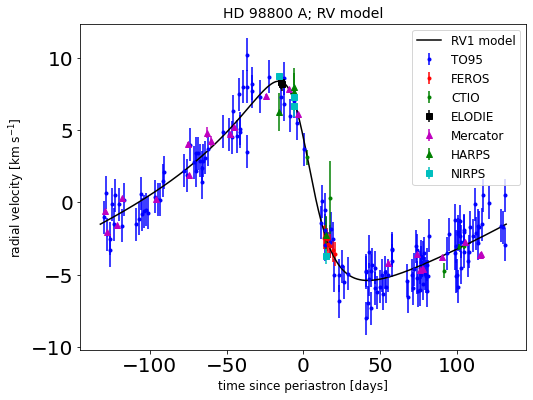

In [35]:
period_RV =  np.percentile(trace["P"], [16,50,84], axis=0)
tp_RV = np.percentile(trace["tp"], [16,50,84], axis=0)
gamma_RV = np.percentile(trace["gamma"], [16,50,84], axis=0)
gamma_FEROS = np.percentile(trace["gamma_FEROS"], [16,50,84], axis=0)
gamma_CTIO = np.percentile(trace["gamma_CTIO"], [16,50,84], axis=0)
gamma_ELODIE = np.percentile(trace["gamma_ELODIE"], [16,50,84], axis=0)
gamma_Mercator = np.percentile(trace["gamma_Mercator"], [16,50,84], axis=0)
gamma_HARPS = np.percentile(trace["gamma_HARPS"], [16,50,84], axis=0)
gamma_NIRPS = np.percentile(trace["gamma_NIRPS"], [16,50,84], axis=0)
K1_RV = np.percentile(trace["K1"], [16,50,84], axis=0)
#K2_RV = np.percentile(trace["K2"], [16,50,84], axis=0)
omega_RV = np.percentile(trace["w"], [16,50,84], axis=0)
ecc_RV = np.percentile(trace["e"], [16,50,84], axis=0)

fig, axes = plt.subplots(figsize=(8, 6))

folded = ((t - tp_RV[1] + 0.5 * period_RV[1]) % period_RV[1]) - 0.5 * period_RV[1]
folded_F = ((t_FEROS - tp_RV[1] + 0.5 * period_RV[1]) % period_RV[1]) - 0.5 * period_RV[1]
folded_C = ((t_CTIO - tp_RV[1] + 0.5 * period_RV[1]) % period_RV[1]) - 0.5 * period_RV[1]
folded_E = ((t_ELODIE - tp_RV[1] + 0.5 *period_RV[1]) % period_RV[1]) - 0.5 * period_RV[1]
folded_M = ((t_Mercator - tp_RV[1] + 0.5 * period_RV[1]) % period_RV[1]) - 0.5 * period_RV[1]
folded_H = ((t_HARPS - tp_RV[1] + 0.5 * period_RV[1]) % period_RV[1]) - 0.5 * period_RV[1]
folded_N = ((t_NIRPS - tp_RV[1] + 0.5 * period_RV[1]) % period_RV[1]) - 0.5 * period_RV[1]
#folded_HAb = ((t_HARPSAb - tp_RV[1] + 0.5 * period_RV[1]) % period_RV[1]) - 0.5 * period_RV[1]
#folded_NAb = ((t_NIRPSAb - tp_RV[1] + 0.5 * period_RV[1]) % period_RV[1]) - 0.5 * period_RV[1]

plt.errorbar(folded, rva - gamma_RV[1], yerr=rva_err, fmt=".b",label="TO95")
plt.errorbar(folded_F, rva_FEROS - gamma_FEROS[1], yerr=rva_err_FEROS, fmt=".r",label="FEROS")
plt.errorbar(folded_C, rva_CTIO - gamma_CTIO[1], yerr=rva_err_CTIO, fmt=".g",label="CTIO")
plt.errorbar(folded_E, rva_ELODIE - gamma_ELODIE[1], yerr=rva_err_ELODIE, fmt="sk",label="ELODIE")
plt.errorbar(folded_M, rva_Mercator - gamma_Mercator[1], yerr=rva_err_Mercator, fmt="^m",label="Mercator")
plt.errorbar(folded_H, rva_HARPS - gamma_HARPS[1], yerr=HARPS_errA, fmt="^g", label="HARPS")
plt.errorbar(folded_N, rva_NIRPS - gamma_NIRPS[1], yerr=NIRPS_errA, fmt="sc", label="NIRPS")
#plt.errorbar(folded_HAb, rvb_HARPS - gamma_HARPS[1], yerr=HARPS_errB, fmt="^r", label="HARPS Ab")
#plt.errorbar(folded_NAb, rvb_NIRPS - gamma_NIRPS[1], yerr=NIRPS_errB, fmt="Dm", label="NIRPS Ab")

x_phase = np.linspace(-0.5 * period_RV[1], 0.5 * period_RV[1], 500)

with model:
    y1_mod = pmx.eval_in_model(model_rv1(x_phase + tp_RV[1], gamma_RV[1]), map_soln)
    #y2_mod = pmx.eval_in_model(model_rv2(x_phase + tp_RV[1], 0), map_soln)

plt.plot(x_phase, y1_mod - gamma_RV[1], "k", label="RV1 model")
#plt.plot(x_phase, y2_mod, "C1--", label="RV2 model")

plt.legend(fontsize=12)
plt.ylabel("radial velocity [$\mathrm{km~s^{-1}}$]", fontsize=12)
plt.xlabel("time since periastron [days]", fontsize=12)
_ = plt.title("HD 98800 A; RV model", fontsize=14)


In [36]:
# Lets try now with a joint-fit (astrometry+RV)

# Read astrometry 
astrometry_elipse_A = pd.read_csv('HD98800A_astrometry.csv')


# The uncertainties in the astrometry from optical interferomtry should be represented with an elipse error
# i.e PA, sigma_maj, sigma_min (see Gallenne et al. 2015). 

t_astro = astrometry_elipse_A['MJD'].to_numpy()
astro_jds = t_astro + 2400000.5 # MJD to JD


x = astrometry_elipse_A['x'].to_numpy()
y = astrometry_elipse_A['y'].to_numpy()

# Semi major axis (sigma_maj) as a astrometry x,y error (to be conservative).
x_err = astrometry_elipse_A['sigma_maj'].to_numpy()
y_err = astrometry_elipse_A['sigma_maj'].to_numpy()

# error elipse
astro_sigma_maj = astrometry_elipse_A['sigma_maj'].to_numpy() #semi-major axis
astro_sigma_min = astrometry_elipse_A['sigma_min'].to_numpy() # semi-minor axis
astrometry_PA = astrometry_elipse_A['PA'].to_numpy() # position angle

# Quick test to visualize the error elipse
#th = np.linspace(0,2*np.pi,100)
#angle = astrometry_PA[1]*deg
#_x, _y = astro_sigma_maj[1]*np.cos(th), astro_sigma_min[1]*np.sin(th)
#_x, _y = _x*np.cos(angle)+_y*np.sin(angle), -_y*np.cos(angle)+_x*np.sin(angle)
#_x += x[1]
#_y += y[1]

#fig, ax = plt.subplots(nrows=1, figsize=(6, 6))
#plt.plot(_x, _y, linestyle='-', color='r', linewidth=2)
#plt.show()

In [37]:
#Now that we have an initial orbit, we can set the model up using PyMC3 to do inference.

yr = 365.25

# for predicted orbits
t_fine = np.linspace(astro_jds.min() - 700, astro_jds.max() + 700, num=1000)


def get_model(parallax=None):
    with pm.Model() as model:

        # Constants (Torres et al. 2010, Gallenne et al. 2019)
        c1 = 1.036149E-7   # M_sun * (km/s)^-3 * d^-1
        c2 = 9.191940E-5   # AU * (km/s)^-1 * d^-1

        # Orbital shape parameters — common to both branches
        logP = pm.Uniform(
            "logP", lower=np.log(250), upper=np.log(270), testval=np.log(period_RV[1])
        )
        P = pm.Deterministic("P", tt.exp(logP))

        Omega_0 = 170 * deg
        omega = pm.Uniform("omega", lower=45*deg, upper=90*deg, testval=omega_RV[1])
        Omega = pm.Uniform("Omega", lower=0.0, upper=2*np.pi, testval=Omega_0)
        ecc = pm.Uniform("ecc", lower=0.1, upper=0.9, testval=ecc_RV[1])
        tp = pm.Normal("tp", mu=tp_RV[1], sd=20, testval=tp_RV[1])

        incl_0 = 135 * deg
        # Geometric uniform prior on cos(incl)
        cos_incl = pm.Uniform("cos_incl", lower=-1, upper=1, testval=np.cos(incl_0))
        incl = pm.Deterministic("incl", tt.arccos(cos_incl))

        # Primary semi-amplitude
        K1 = pm.Uniform("K1", lower=1, upper=30, testval=K1_RV[1])

        if parallax is not None:
            # ---- Parallax known: dynamical mass approach ----
            m_plx = pm.Bound(pm.Normal, lower=10, upper=30)(
                "m_plx", mu=parallax[0], sd=parallax[1], testval=parallax[0]
            )
            plx = pm.Deterministic("plx", 1e-3 * m_plx)

            # M_2 is free; a, M_t, K2 derived
            M_2 = pm.Uniform('M_2', 0.1, 0.9, testval=0.2)
            a = pm.Deterministic('a',
                ((M_2 * (c2**2) * P * tt.sin(incl)) / (c1 * K1 * (1 - ecc**2)**(1/2)))**(1/2)
            )
            M_t = pm.Deterministic("M_t", (a)**3 / (P/yr)**2)
            a_ang = pm.Deterministic("a_ang", plx * a)
            K2 = pm.Deterministic("K2", (K1 * (M_t - M_2)) / M_2)

        else:
            # ---- No parallax: orbit in angular units (plx = 1 arcsec/AU trick) ----
            # a_ang is constrained by interferometric astrometry.
            # K2 is a free parameter constrained by the Ab RVs.
            # Physical parameters (masses, a_AU, plx_save) are derived a posteriori.
            
            plx = 1  # arcsec (positions in arcsec ≡ positions in AU at 1 pc)

            a_ang_0 = 0.019  # arcsec ≈ 19 mas (≈ 0.84 AU at 44 pc)
            a_ang = pm.Uniform("a_ang", 0.005, 0.3, testval=a_ang_0)
            a = pm.Deterministic("a", a_ang / plx)  # AU = a_ang arcsec (with plx=1)

            #
            # NOTE: For AaAb at ~44 pc with a_ang ~ 19 mas = 0.019 arcsec,
            #   a_AU = c2*(K1+K2)*P*sqrt(1-e²)/sin(i) ~ 0.9 AU
            #   → K1+K2 ~ 30 km/s  →  K2 ~ 25 km/s
            # The prior must reach at least 30 km/s.
            #K2 = pm.Uniform("K2", lower=1, upper=50, testval=K2_RV[1])

            # Individual stellar masses (Torres et al. 2010, eq. 10)
            #M1_save = pm.Deterministic("M1_save",
            #    (c1 * (K1 + K2)**2 * K2 * P * (1 - ecc**2)**(3.0/2)) / tt.sin(incl)**3)
            #M2_save = pm.Deterministic("M2_save",
            #    (c1 * (K1 + K2)**2 * K1 * P * (1 - ecc**2)**(3.0/2)) / tt.sin(incl)**3)
            #pm.Deterministic("Mt_save", M1_save + M2_save)

            # Physical semi-major axis in AU from the SB2 velocity amplitudes
            #a_AU = pm.Deterministic("a_AU",
            #    (c2 * (K1 + K2) * P * (1 - ecc**2)**(1/2)) / tt.sin(incl))

            # Implied parallax (mas): plx = a_ang [arcsec] / a_AU [AU] * 1000
            # Should converge to ~22 mas (Gaia parallax of HD 98800)
            #pm.Deterministic("plx_save", (a_ang / a_AU) * 1000)

        # Set up the Keplerian orbit
        orbit = xo.orbits.KeplerianOrbit(
            a=a * au_to_R_sun,
            t_periastron=tp,
            period=P,
            incl=incl,
            ecc=ecc,
            omega=omega,
            Omega=Omega,
        )

        # Systemic velocities — one per instrument
        gamma = pm.Uniform("gamma", lower=0, upper=20, testval=12)
        gamma_FEROS = pm.Uniform("gamma_FEROS", lower=0, upper=20, testval=14)
        gamma_FEROS2 = pm.Uniform("gamma_FEROS2", lower=0, upper=20, testval=14)
        gamma_CTIO = pm.Uniform("gamma_CTIO", lower=0, upper=30, testval=10)
        gamma_ELODIE = pm.Uniform("gamma_ELODIE", lower=0, upper=30, testval=10)
        gamma_Mercator = pm.Uniform("gamma_Mercator", lower=0, upper=30, testval=10)
        gamma_HARPS = pm.Uniform("gamma_HARPS", lower=0, upper=30, testval=12)
        gamma_NIRPS = pm.Uniform("gamma_NIRPS", lower=0, upper=30, testval=12)

        # Jitter parameters — separate for primary (A) and secondary (B) for SB2 instruments
        logjit_TO95 = pm.Uniform("logjitterTO95", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_FEROS = pm.Uniform("logjitterFEROS", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_FEROS2 = pm.Uniform("logjitterFEROS2", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_CTIO = pm.Uniform("logjitterCTIO", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_ELODIE = pm.Uniform("logjitterELODIE", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_Mercator = pm.Uniform("logjitterMercator", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_HARPS_A = pm.Uniform("logjitterHARPS_A", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        #logjit_HARPS_B = pm.Uniform("logjitterHARPS_B", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        logjit_NIRPS_A = pm.Uniform("logjitterNIRPS_A", lower=-5.0, upper=np.log(10), testval=np.log(1.0))
        #logjit_NIRPS_B = pm.Uniform("logjitterNIRPS_B", lower=-5.0, upper=np.log(10), testval=np.log(1.0))

        jit_TO95 = pm.Deterministic("jitTO95", tt.exp(logjit_TO95))
        jit_FEROS = pm.Deterministic("jitFEROS", tt.exp(logjit_FEROS))
        jit_FEROS2 = pm.Deterministic("jitFEROS2", tt.exp(logjit_FEROS2))
        jit_CTIO = pm.Deterministic("jitCTIO", tt.exp(logjit_CTIO))
        jit_ELODIE = pm.Deterministic("jitELODIE", tt.exp(logjit_ELODIE))
        jit_Mercator = pm.Deterministic("jitMercator", tt.exp(logjit_Mercator))
        jit_HARPS_A = pm.Deterministic("jitHARPS_A", tt.exp(logjit_HARPS_A))
        #jit_HARPS_B = pm.Deterministic("jitHARPS_B", tt.exp(logjit_HARPS_B))
        jit_NIRPS_A = pm.Deterministic("jitNIRPS_A", tt.exp(logjit_NIRPS_A))
        #jit_NIRPS_B = pm.Deterministic("jitNIRPS_B", tt.exp(logjit_NIRPS_B))

        # Total error helper
        def get_err(rv_err, logjitter):
            return tt.sqrt(rv_err**2 + tt.exp(2*logjitter))

        # RV models: primary (Aa) and secondary (Ab)
        def model_rv1(jd, offset):
            return offset + orbit.get_radial_velocity(jd, K=K1)

        #def model_rv2(jd, offset):
        #    return offset - orbit.get_radial_velocity(jd, K=K2)

        # Primary (Aa) — all instruments
        rvmodel_a = pm.Deterministic("rvmodel_a", model_rv1(t, gamma))
        rvmodel_a_FEROS = pm.Deterministic("rvmodel_a_FEROS", model_rv1(t_FEROS, gamma_FEROS))
        rvmodel_a_FEROS2 = pm.Deterministic("rvmodel_a_FEROS2", model_rv1(t_FEROS2, gamma_FEROS2))
        rvmodel_a_CTIO = pm.Deterministic("rvmodel_a_CTIO", model_rv1(t_CTIO, gamma_CTIO))
        rvmodel_a_ELODIE = pm.Deterministic("rvmodel_a_ELODIE", model_rv1(t_ELODIE, gamma_ELODIE))
        rvmodel_a_Mercator = pm.Deterministic("rvmodel_a_Mercator", model_rv1(t_Mercator, gamma_Mercator))
        rvmodel_a_HARPS = pm.Deterministic("rvmodel_a_HARPS", model_rv1(t_HARPS, gamma_HARPS))
        rvmodel_a_NIRPS = pm.Deterministic("rvmodel_a_NIRPS", model_rv1(t_NIRPS, gamma_NIRPS))

        # Secondary (Ab) — HARPS and NIRPS only
        #rvmodel_b_HARPS = pm.Deterministic("rvmodel_b_HARPS", model_rv2(t_HARPSAb, gamma_HARPS))
        #rvmodel_b_NIRPS = pm.Deterministic("rvmodel_b_NIRPS", model_rv2(t_NIRPSAb, gamma_NIRPS))

        # Likelihoods — Primary
        pm.Normal("obs_a", mu=rvmodel_a, sd=get_err(rva_err, logjit_TO95), observed=rva)
        pm.Normal("obs_a_FEROS", mu=rvmodel_a_FEROS, sd=get_err(rva_err_FEROS, logjit_FEROS), observed=rva_FEROS)
        pm.Normal("obs_a_FEROS2", mu=rvmodel_a_FEROS2, sd=get_err(rva_err_FEROS2, logjit_FEROS2), observed=rva_FEROS2)
        pm.Normal("obs_a_CTIO", mu=rvmodel_a_CTIO, sd=get_err(rva_err_CTIO, logjit_CTIO), observed=rva_CTIO)
        pm.Normal("obs_a_ELODIE", mu=rvmodel_a_ELODIE, sd=get_err(rva_err_ELODIE, logjit_ELODIE), observed=rva_ELODIE)
        pm.Normal("obs_a_Mercator", mu=rvmodel_a_Mercator, sd=get_err(rva_err_Mercator, logjit_Mercator), observed=rva_Mercator)
        pm.Normal("obs_a_HARPS", mu=rvmodel_a_HARPS, sd=get_err(rva_err_HARPS, logjit_HARPS_A), observed=rva_HARPS)
        pm.Normal("obs_a_NIRPS", mu=rvmodel_a_NIRPS, sd=get_err(rva_err_NIRPS, logjit_NIRPS_A), observed=rva_NIRPS)

        # Likelihoods — Secondary (Ab)
        #pm.Normal("obs_b_HARPS", mu=rvmodel_b_HARPS, sd=get_err(rvb_err_HARPS, logjit_HARPS_B), observed=rvb_HARPS)
        #pm.Normal("obs_b_NIRPS", mu=rvmodel_b_NIRPS, sd=get_err(rvb_err_NIRPS, logjit_NIRPS_B), observed=rvb_NIRPS)

        # Save O-C residuals
        pm.Deterministic("OC_CTIOa", (rva_CTIO - rvmodel_a_CTIO))
        pm.Deterministic("OC_FEROSa", (rva_FEROS - rvmodel_a_FEROS))
        pm.Deterministic("OC_FEROSa2", (rva_FEROS2 - rvmodel_a_FEROS2))
        pm.Deterministic("OC_ELOa", (rva_ELODIE - rvmodel_a_ELODIE))
        pm.Deterministic("OC_Mercatora", (rva_Mercator - rvmodel_a_Mercator))
        pm.Deterministic("OC_HARPSa", (rva_HARPS - rvmodel_a_HARPS))
        pm.Deterministic("OC_NIRPSa", (rva_NIRPS - rvmodel_a_NIRPS))
        #pm.Deterministic("OC_HARPSb", (rvb_HARPS - rvmodel_b_HARPS))
        #pm.Deterministic("OC_NIRPSb", (rvb_NIRPS - rvmodel_b_NIRPS))

        # Astrometry model — relative position (Aa relative to Ab)
        y_model, x_model, z_model = orbit.get_relative_position(astro_jds, plx)
        pm.Deterministic("x_model", x_model)
        pm.Deterministic("y_model", y_model)

        # Ellipse error model
        Maj_err = (x_model - x/1000)*tt.cos(astrometry_PA*deg) + (y_model - y/1000)*tt.sin(astrometry_PA*deg)
        Min_err = -(y_model - y/1000)*tt.cos(astrometry_PA*deg) + (x_model - x/1000)*tt.sin(astrometry_PA*deg)

        pm.Deterministic('Maj_err', Maj_err*1000)
        pm.Deterministic('Min_err', Min_err*1000)

        pm.Normal("sigmaMaj_obs", mu=Maj_err, sd=astro_sigma_maj/1000, observed=0.0)
        pm.Normal("sigmaMin_obs", mu=Min_err, sd=astro_sigma_min/1000, observed=0.0)

        # Predicted orbits for plotting
        y_dense, x_dense, z_dense = orbit.get_relative_position(t_fine, plx)
        x_save = pm.Deterministic("x_save", x_dense)
        y_save = pm.Deterministic("y_save", y_dense)

        va_dense = orbit.get_radial_velocity(t_fine, K1)
        #vb_dense = orbit.get_radial_velocity(t_fine, K2)
        va_save = pm.Deterministic("va_save", va_dense)
        #vb_save = pm.Deterministic("vb_save", vb_dense)

        # Optimize the MAP solution
        map_soln = model.test_point
        map_soln = pmx.optimize(map_soln)

    return model, map_soln

model, map_soln = get_model()


optimizing logp for variables: [logjitterNIRPS_A, logjitterHARPS_A, logjitterMercator, logjitterELODIE, logjitterCTIO, logjitterFEROS2, logjitterFEROS, logjitterTO95, gamma_NIRPS, gamma_HARPS, gamma_Mercator, gamma_ELODIE, gamma_CTIO, gamma_FEROS2, gamma_FEROS, gamma, a_ang, K1, cos_incl, tp, ecc, Omega, omega, logP]


message: Desired error not necessarily achieved due to precision loss.
logp: -18363.024004742118 -> -303.9039300924764


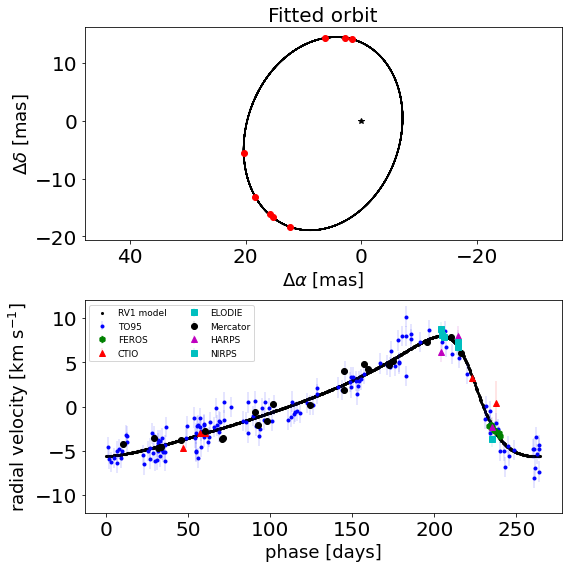

In [38]:
period = map_soln['P']
tp = map_soln['tp']
gamma = map_soln['gamma']
gamma_FEROS = map_soln['gamma_FEROS']
gamma_CTIO = map_soln['gamma_CTIO']
gamma_ELODIE = map_soln['gamma_ELODIE']
gamma_Mercator = map_soln['gamma_Mercator']
gamma_HARPS = map_soln['gamma_HARPS']
gamma_NIRPS = map_soln['gamma_NIRPS']

# Jitter-inflated errors from MAP solution
HARPS_errA = np.sqrt(rva_err_HARPS**2 + np.exp(2 * map_soln["logjitterHARPS_A"]))
#HARPS_errB = np.sqrt(rvb_err_HARPS**2 + np.exp(2 * map_soln["logjitterHARPS_B"]))
NIRPS_errA = np.sqrt(rva_err_NIRPS**2 + np.exp(2 * map_soln["logjitterNIRPS_A"]))
#NIRPS_errB = np.sqrt(rvb_err_NIRPS**2 + np.exp(2 * map_soln["logjitterNIRPS_B"]))

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

ax = axes[0]
ax.set_ylabel(r"$\Delta \delta$ [mas]", fontsize=18)
ax.errorbar(x, y, yerr=y_err, xerr=x_err, fmt="or")
ax.plot(map_soln["x_save"]*1000, map_soln["y_save"]*1000, color="k")
ax.set_xlabel(r"$\Delta \alpha$ [mas]", fontsize=18)
ax.invert_xaxis()
ax.plot(0, 0, "k*")
ax.set_aspect("equal", "datalim")
ax.set_title("Fitted orbit", fontsize=20)

ax = axes[1]
ax.errorbar(t % period, rva - gamma, yerr=rva_err, fmt=".b", label="TO95", lw=0.2)
ax.errorbar(t_FEROS % period, rva_FEROS - gamma_FEROS, yerr=rva_err_FEROS, fmt="hg", label="FEROS", lw=0.2)
ax.errorbar(t_CTIO % period, rva_CTIO - gamma_CTIO, yerr=rva_err_CTIO, fmt="^r", label="CTIO", lw=0.2)
ax.errorbar(t_ELODIE % period, rva_ELODIE - gamma_ELODIE, yerr=rva_err_ELODIE, fmt="sc", label="ELODIE", lw=0.2)
ax.errorbar(t_Mercator % period, rva_Mercator - gamma_Mercator, yerr=rva_err_Mercator, fmt="ok", label="Mercator", lw=0.2)
ax.errorbar(t_HARPS % period, rva_HARPS - gamma_HARPS, yerr=HARPS_errA, fmt="^m", label="HARPS", lw=0.2)
ax.errorbar(t_NIRPS % period, rva_NIRPS - gamma_NIRPS, yerr=NIRPS_errA, fmt="sc", label="NIRPS", lw=0.2)
#ax.errorbar(t_HARPSAb % period, rvb_HARPS - gamma_HARPS, yerr=HARPS_errB, fmt="^r", label="HARPS Ab", lw=0.2)
#ax.errorbar(t_NIRPSAb % period, rvb_NIRPS - gamma_NIRPS, yerr=NIRPS_errB, fmt="Dm", label="NIRPS Ab", lw=0.2)

# RV1 (Aa) and RV2 (Ab) model curves
ax.scatter(t_fine % period, map_soln["va_save"], color="k", marker='.', lw=0.1, label="RV1 model")
#ax.scatter(t_fine % period, -map_soln["vb_save"], color="C1", marker='.', lw=0.1, label="RV2 model")

ax.legend(fontsize=9, ncol=2)
ax.set_ylabel("radial velocity [$\mathrm{km~s^{-1}}$]", fontsize=18)
ax.set_xlabel("phase [days]", fontsize=18)

axes[1].set_ylim(-12, 12)

plt.tight_layout()


In [39]:
#That looks fine, so now we can run the MCMC sampler:
np.random.seed(39091)
with model:
    trace = pmx.sample(
        tune=2500, draws=2000, start=map_soln, chains=7, cores=7, target_accept=0.95, init="adapt_full",
    )

/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/pymc3_ext/sampling/sampling.py:109: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return pm.sample(draws=draws, tune=tune, model=model, step=step, **kwargs)
Multiprocess sampling (7 chains in 7 jobs)
INFO:pymc3:Multiprocess sampling (7 chains in 7 jobs)
NUTS: [logjitterNIRPS_A, logjitterHARPS_A, logjitterMercator, logjitterELODIE, logjitterCTIO, logjitterFEROS2, logjitterFEROS, logjitterTO95, gamma_NIRPS, gamma_HARPS, gamma_Mercator, gamma_ELODIE, gamma_CTIO, gamma_FEROS2, gamma_FEROS, gamma, a_ang, K1, cos_incl, tp, ecc, Omega, omega, logP]
INFO:pymc3:NUTS: [logjitterNIRPS_A, logjitterHARPS_A, logjitterMercator, logjitterELODIE, logjitterCTIO, logjitterFEROS2, logjitterFEROS, logjitterTO95, gamma_NIRPS, gamma_HARPS, gamma_Mercato

/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  ret

In [40]:
# Then we can look at some summaries of the trace and the constraints on some of the key parameters:
with model:
    summary = pm.summary(
        trace,
        var_names=["P", "tp", "a_ang", "omega", "Omega", "incl", "ecc", 'K1'],
        round_to=4
    )
    
summary

#print(summary[['mean','sd','hdi_3%','hdi_97%','ess_bulk','ess_tail','r_hat']].to_latex())

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
P,2.645071e+02,0.0194,2.644698e+02,2.645421e+02,0.0002,0.0001,13878.1022,9522.7886,1.0009
tp,2.448743e+06,0.7578,2.448742e+06,2.448744e+06,0.0064,0.0045,14091.1107,9713.9306,1.0009
a_ang,1.900000e-02,0.0000,1.900000e-02,1.910000e-02,0.0000,0.0000,14472.4265,9592.9462,1.0002
omega,1.199100e+00,0.0017,1.195900e+00,1.202300e+00,0.0000,0.0000,13463.3011,10172.3743,1.0003
Omega,2.970100e+00,0.0025,2.965400e+00,2.975000e+00,0.0000,0.0000,13638.6696,10113.6966,1.0007
incl,2.366500e+00,0.0020,2.362700e+00,2.370300e+00,0.0000,0.0000,14685.7497,10221.8655,1.0009
ecc,4.808000e-01,0.0008,4.793000e-01,4.824000e-01,0.0000,0.0000,14165.6654,9162.8383,1.0004
K1,6.787300e+00,0.1372,6.534200e+00,7.045600e+00,0.0012,0.0008,14177.9857,8958.1650,1.0006


Period (days): 264.507$\pm$0.019
Tp (MJD): 48742.46$\pm$0.74
omega (deg): 68.704$\pm$0.098
Omega (deg): 170.17$\pm$0.15
i (deg): 135.59$\pm$0.12
a (mas): 19.036$\pm$0.015
e: 0.48081$\pm$0.00084
K1 (km/s): 6.79$\pm$0.14
gamma TO95 (km/s): 12.839$\pm$0.099
gamma Mercator (km/s): 12.86$\pm$0.17
gamma FEROS (km/s): 14.33$\pm$0.31
gamma FEROS 2 (km/s): 11.9$\pm$1.2
gamma CTIO (km/s): 11.86$\pm$0.18
gamma ELODIE (km/s): 12.08$\pm$0.47
gamma HARPS (km/s): 11.79$\pm$0.78
gamma NIRPS (km/s): 11.54$\pm$0.64


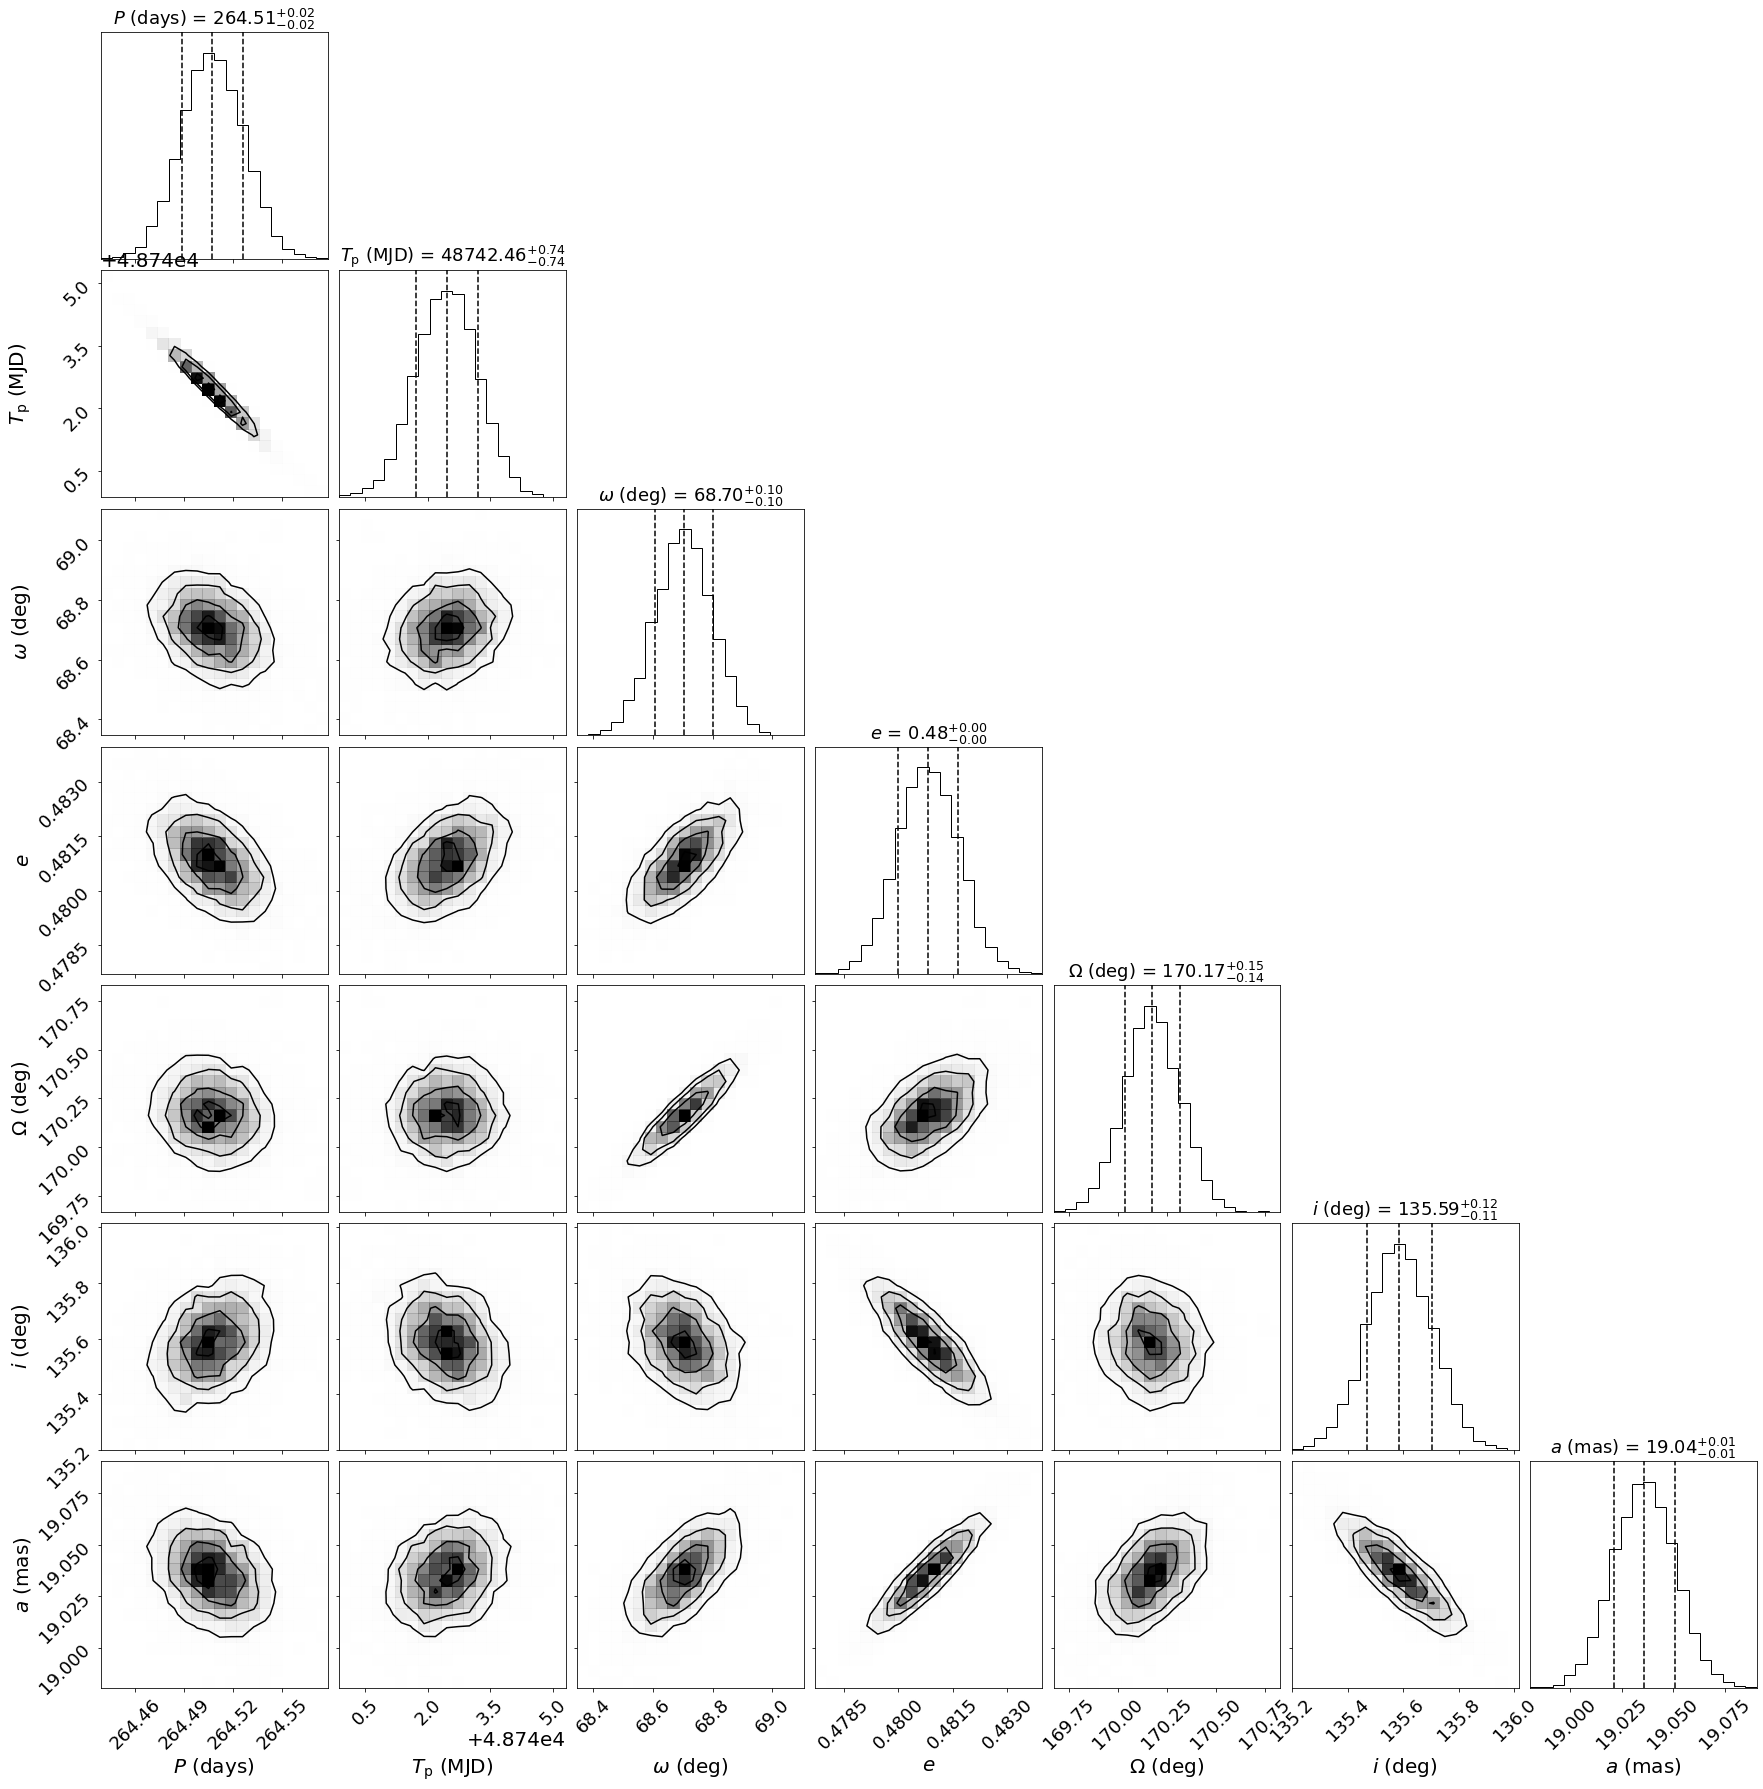

In [57]:

samples = pm.trace_to_dataframe(trace, varnames=["Omega"])
samples["$P$ (days)"] = trace["P"]
samples["$T_\mathrm{p}$ (MJD)"] = trace["tp"] - 2400000.5
samples["$\omega$ (deg)"] = (trace["omega"] * rad_2_deg) % 360
samples["$e$"] = trace["ecc"]
samples["$\Omega$ (deg)"] = (trace["Omega"] / deg) % 360
samples["$i$ (deg)"] = (trace["incl"] / deg) % 360
samples["$a$ (mas)"] = trace["a_ang"] * 1000

period, period_s = get_median_sigma(trace["P"])
print("Period (days): "+fmt(period, period_s))

tp, tp_s = get_median_sigma(trace["tp"]- 2400000.5)
print("Tp (MJD): "+fmt(tp, tp_s))

omega, omega_s = get_median_sigma((trace["omega"] * rad_2_deg) % 360)
print("omega (deg): "+fmt(omega, omega_s))

Omega, Omega_s = get_median_sigma((trace["Omega"] * rad_2_deg) % 360)
print("Omega (deg): "+fmt(Omega, Omega_s))

inc, inc_s = get_median_sigma((trace["incl"] * rad_2_deg) % 180)
print("i (deg): "+fmt(inc, inc_s))

aang, aang_s = get_median_sigma(trace["a_ang"]*1000)
print("a (mas): "+fmt(aang, aang_s))

ecc, ecc_s = get_median_sigma(trace["ecc"])
print("e: "+fmt(ecc, ecc_s))

K1, K1_s = get_median_sigma(trace["K1"])
print("K1 (km/s): "+fmt(K1, K1_s))

#K2, K2_s = get_median_sigma(trace["K2"])
#print("K2 (km/s): "+fmt(K2, K2_s))

gamma, gamma_s = get_median_sigma(trace["gamma"])
print("gamma TO95 (km/s): "+fmt(gamma, gamma_s))

gammaM, gammaM_s = get_median_sigma(trace["gamma_Mercator"])
print("gamma Mercator (km/s): "+fmt(gammaM, gammaM_s))

gammaF, gammaF_s = get_median_sigma(trace["gamma_FEROS"])
print("gamma FEROS (km/s): "+fmt(gammaF, gammaF_s))

gammaF2, gammaF2_s = get_median_sigma(trace["gamma_FEROS2"])
print("gamma FEROS 2 (km/s): "+fmt(gammaF2, gammaF2_s))

gammaC, gammaC_s = get_median_sigma(trace["gamma_CTIO"])
print("gamma CTIO (km/s): "+fmt(gammaC, gammaC_s))

gammaE, gammaE_s = get_median_sigma(trace["gamma_ELODIE"])
print("gamma ELODIE (km/s): "+fmt(gammaE, gammaE_s))

gammaH, gammaH_s = get_median_sigma(trace["gamma_HARPS"])
print("gamma HARPS (km/s): "+fmt(gammaH, gammaH_s))

gammaN, gammaN_s = get_median_sigma(trace["gamma_NIRPS"])
print("gamma NIRPS (km/s): "+fmt(gammaN, gammaN_s))

del samples["Omega"]

samples.to_csv("CSV/AaAb_orbit_parameters_posteriors.csv", index=False)

figure = corner.corner(samples.to_numpy(), labels=list(samples.columns),
                  quantiles=[0.16, 0.5, 0.84], show_titles=True,
                  title_kwargs={"fontsize": 18}, label_kwargs=dict(fontsize=20), plot_datapoints=False)

figure.subplots_adjust(right=1.5, top=1.5)

for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=18)

figure.savefig('Plots/AaAb_corner_orbit.pdf', dpi=300, pad_inches=0.3, bbox_inches='tight')



K1 (km/s): 6.79$\pm$0.14
gamma TO95 (km/s): 12.839$\pm$0.099
gamma FEROS (km/s): 14.33$\pm$0.31
gamma FEROS 2 (km/s): 11.9$\pm$1.2
gamma CTIO (km/s): 11.86$\pm$0.18
gamma ELODIE (km/s): 12.08$\pm$0.47
gamma Mercator (km/s): 12.86$\pm$0.17
gamma HARPS (km/s): 11.79$\pm$0.78
gamma NIRPS (km/s): 11.54$\pm$0.64
Too few points to create valid contours


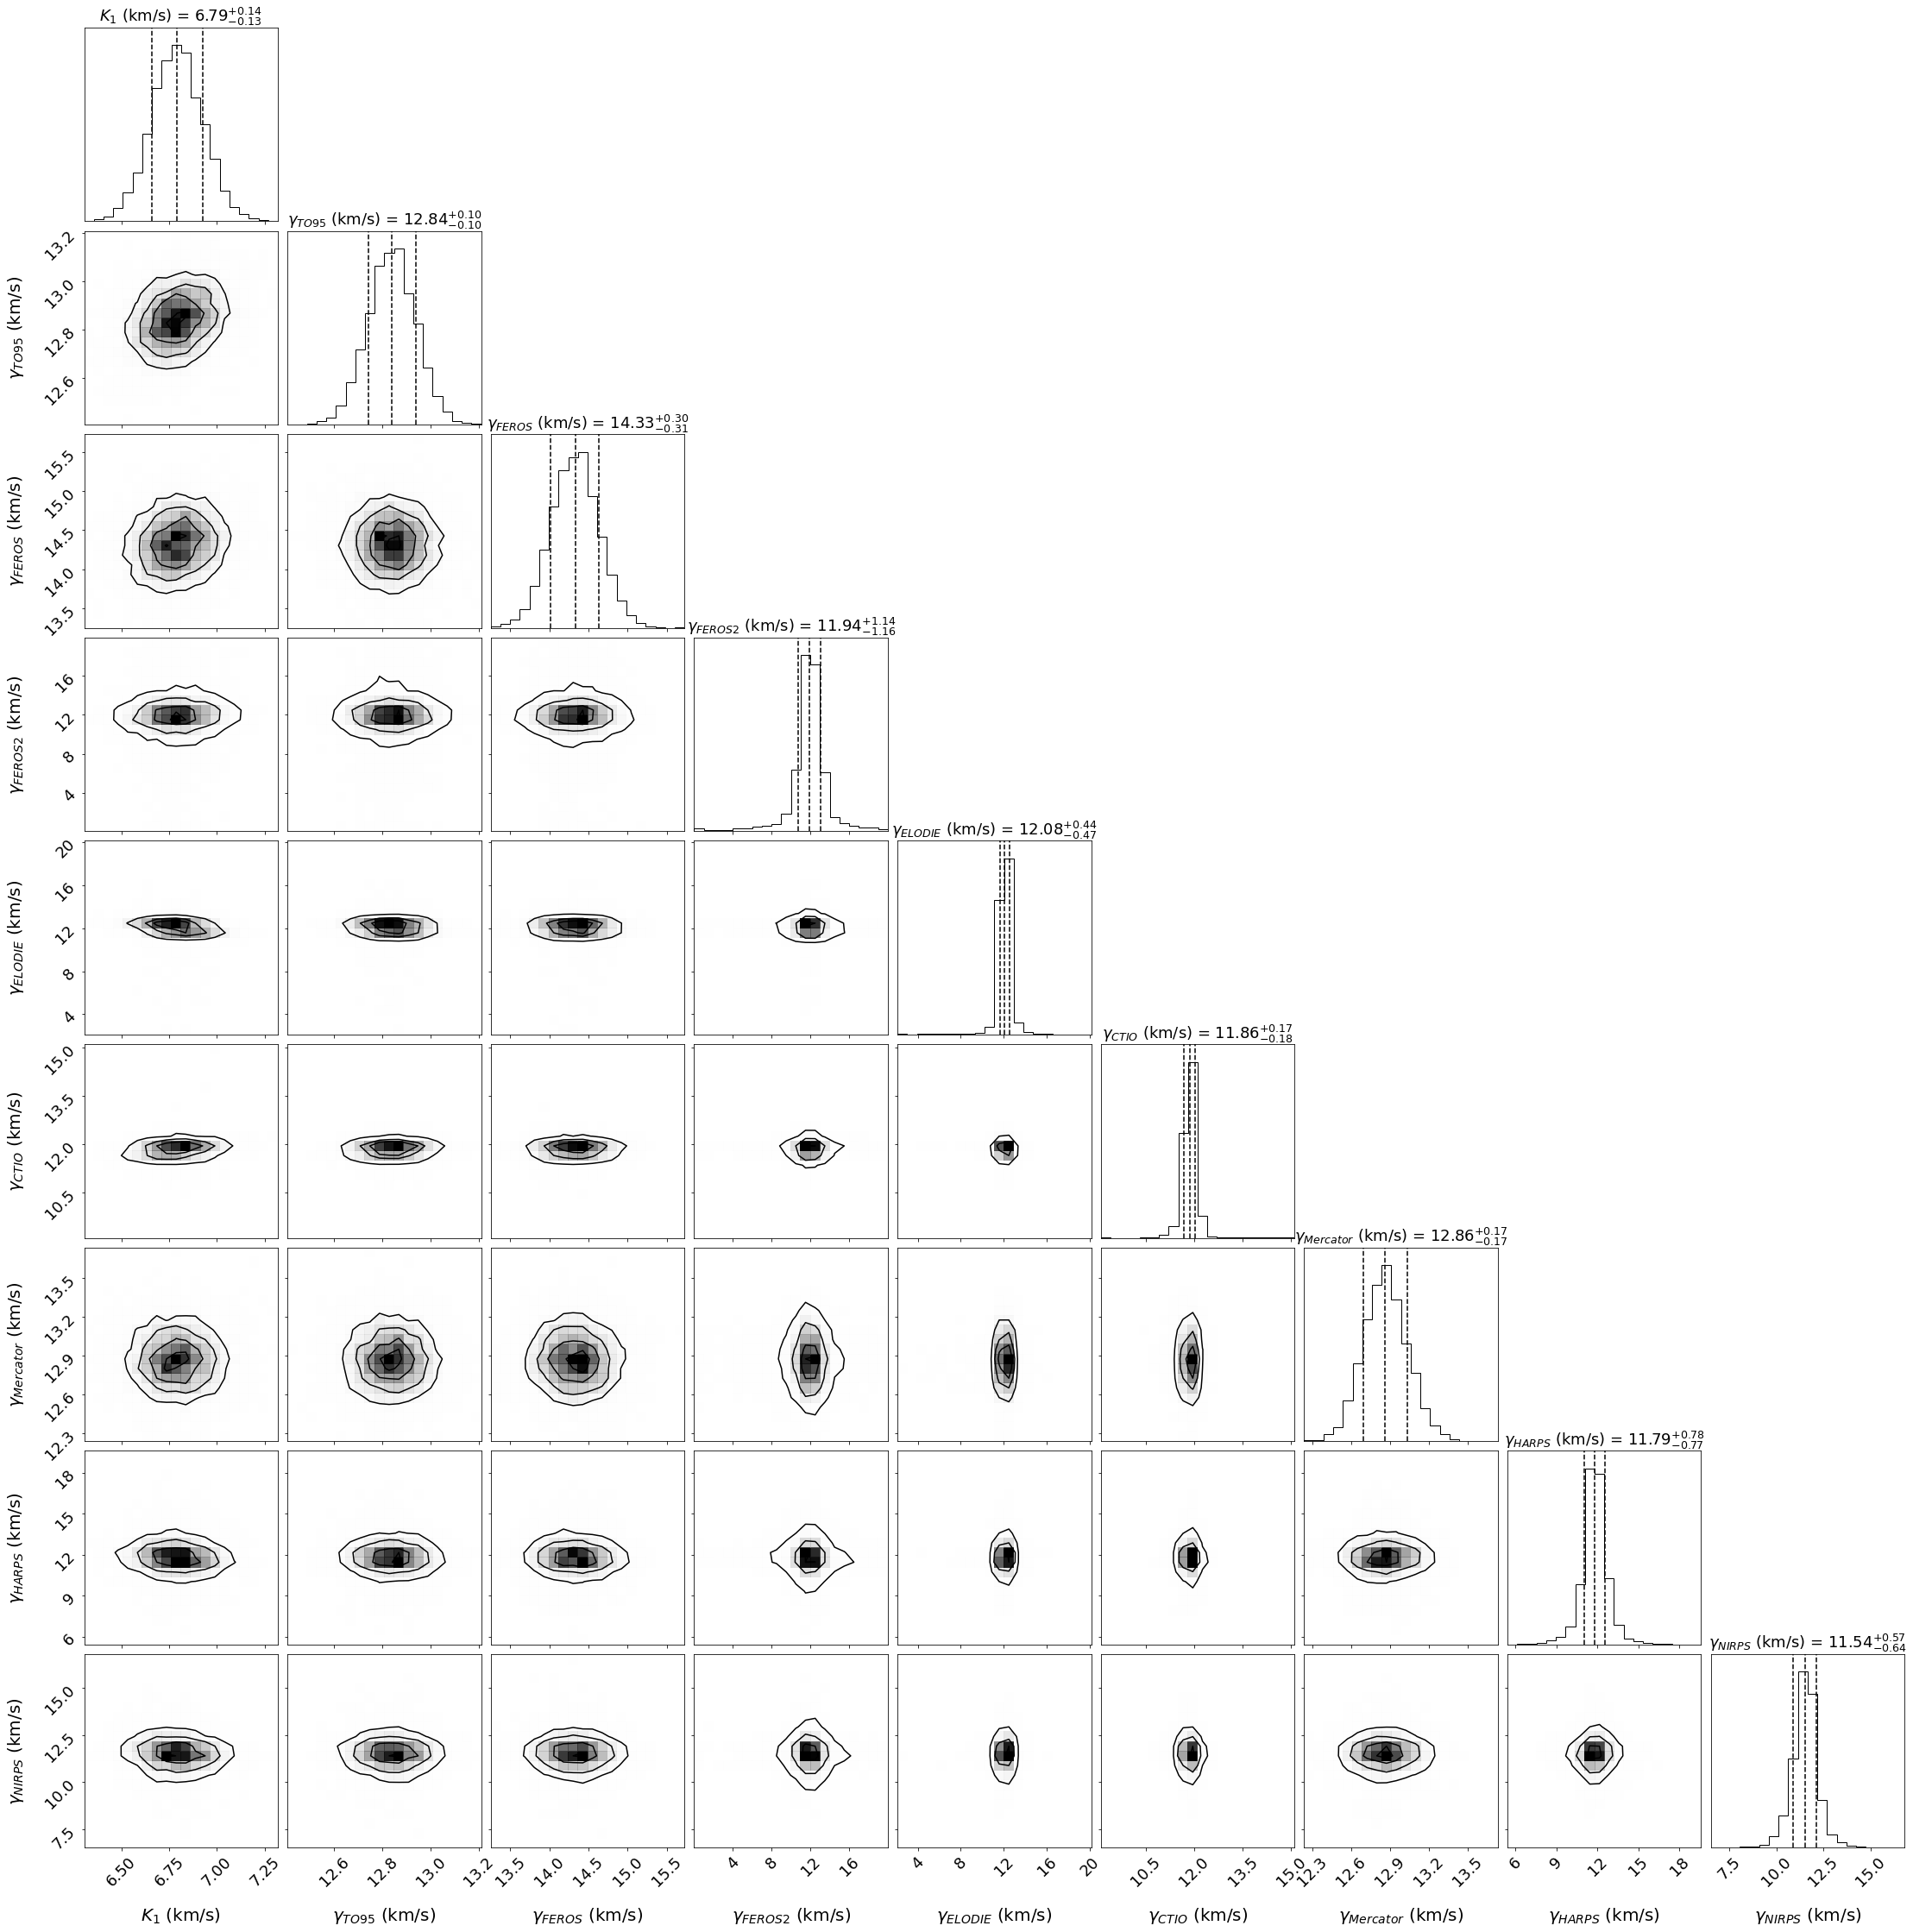

In [55]:
samples = pm.trace_to_dataframe(trace, varnames=["Omega"])
samples["$K_1$ (km/s)"] = trace["K1"]
#samples["$K_2$ (km/s)"] = trace["K2"]
#samples["$M_1$ ($M_\odot$)"] = trace["M1_save"]
#samples["$M_2$ ($M_\odot$)"] = trace["M2_save"]
#samples["$a$ [AU]"] = trace["a_AU"]
#samples["$\pi$ [mas]"] = trace["plx_save"]
samples["$\gamma_{TO95}$ (km/s)"] = trace["gamma"]
samples["$\gamma_{FEROS}$ (km/s)"] = trace["gamma_FEROS"]
samples["$\gamma_{FEROS2}$ (km/s)"] = trace["gamma_FEROS2"]
samples["$\gamma_{ELODIE}$ (km/s)"] = trace["gamma_ELODIE"]
samples["$\gamma_{CTIO}$ (km/s)"] = trace["gamma_CTIO"]
samples["$\gamma_{Mercator}$ (km/s)"] = trace["gamma_Mercator"]
samples["$\gamma_{HARPS}$ (km/s)"] = trace["gamma_HARPS"]
samples["$\gamma_{NIRPS}$ (km/s)"] = trace["gamma_NIRPS"]

K1, K1_s = get_median_sigma(trace["K1"])
print("K1 (km/s): "+fmt(K1, K1_s))

#K2, K2_s = get_median_sigma(trace["K2"])
#print("K2 (km/s): "+fmt(K2, K2_s))

#M1, M1_s = get_median_sigma(trace["M1_save"])
#print("M1 (Msun): "+fmt(M1, M1_s))

#M2, M2_s = get_median_sigma(trace["M2_save"])
#print("M2 (Msun): "+fmt(M2, M2_s))

#a, a_s = get_median_sigma(trace["a_AU"])
#print("a (AU): "+fmt(a, a_s))

#plx, plx_s = get_median_sigma(trace["plx_save"])
#print("plx (mas): "+fmt(plx, plx_s))

gamma, gamma_s = get_median_sigma(trace["gamma"])
print("gamma TO95 (km/s): "+fmt(gamma, gamma_s))

gammaL, gammaL_s = get_median_sigma(trace["gamma_FEROS"])
print("gamma FEROS (km/s): "+fmt(gammaL, gammaL_s))

gammaL, gammaL_s = get_median_sigma(trace["gamma_FEROS2"])
print("gamma FEROS 2 (km/s): "+fmt(gammaL, gammaL_s))

gammaC, gammaC_s = get_median_sigma(trace["gamma_CTIO"])
print("gamma CTIO (km/s): "+fmt(gammaC, gammaC_s))

gammaE, gammaE_s = get_median_sigma(trace["gamma_ELODIE"])
print("gamma ELODIE (km/s): "+fmt(gammaE, gammaE_s))

gammaM, gammaM_s = get_median_sigma(trace["gamma_Mercator"])
print("gamma Mercator (km/s): "+fmt(gammaM, gammaM_s))

gammaH, gammaH_s = get_median_sigma(trace["gamma_HARPS"])
print("gamma HARPS (km/s): "+fmt(gammaH, gammaH_s))

gammaN, gammaN_s = get_median_sigma(trace["gamma_NIRPS"])
print("gamma NIRPS (km/s): "+fmt(gammaN, gammaN_s))

del samples["Omega"]

samples.to_csv("CSV/AaAb_K_gamma_posteriors.csv", index=False)

figure = corner.corner(samples.to_numpy(), labels=list(samples.columns),
                  quantiles=[0.16, 0.5, 0.84], show_titles=True,
                  title_kwargs={"fontsize": 18}, label_kwargs=dict(fontsize=20), plot_datapoints=False)

figure.subplots_adjust(right=1.5, top=1.5)

for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=18)

figure.savefig('Plots/AaAb_corner_RVs.pdf', dpi=300, pad_inches=0.3, bbox_inches='tight')


In [43]:

latex_table = (
    r"\begin{table}" + "\n"
    r"\centering" + "\n"
    r"\caption{Orbital and spectroscopic parameters of HD\,98800\,AaAb}" + "\n"
    r"\begin{tabular}{lc}" + "\n"
    r"\hline\hline" + "\n"
    r"Parameter & Value \\" + "\n"
    r"\hline" + "\n"
    f"$P$ (days) & ${period:.2f} \\pm {period_s:.2f}$ \\\\\n"
    f"$T_{{\\rm p}}$ (MJD) & ${tp:.1f} \\pm {tp_s:.1f}$ \\\\\n"
    f"$\\omega$ (deg) & ${omega:.1f} \\pm {omega_s:.1f}$ \\\\\n"
    f"$\\Omega$ (deg) & ${Omega:.1f} \\pm {Omega_s:.1f}$ \\\\\n"
    f"$i$ (deg) & ${inc:.1f} \\pm {inc_s:.1f}$ \\\\\n"
    f"$a$ (mas) & ${aang:.2f} \\pm {aang_s:.2f}$ \\\\\n"
    f"$e$ & ${ecc:.4f} \\pm {ecc_s:.4f}$ \\\\\n"
    f"$K_1$ (km\\,s$^{{-1}}$) & ${K1:.1f} \\pm {K1_s:.1f}$ \\\\\n"
    f"$\\gamma_{{\\rm TO95}}$ (km\\,s$^{{-1}}$) & ${gamma:.1f} \\pm {gamma_s:.1f}$ \\\\\n"
    f"$\\gamma_{{\\rm Mercator}}$ (km\\,s$^{{-1}}$) & ${gammaM:.1f} \\pm {gammaM_s:.1f}$ \\\\\n"
    f"$\\gamma_{{\\rm FEROS}}$ (km\\,s$^{{-1}}$) & ${gammaF:.1f} \\pm {gammaF_s:.1f}$ \\\\\n"
    f"$\\gamma_{{\\rm FEROS2}}$ (km\\,s$^{{-1}}$) & ${gammaF2:.0f} \\pm {gammaF2_s:.0f}$ \\\\\n"
    f"$\\gamma_{{\\rm CTIO}}$ (km\\,s$^{{-1}}$) & ${gammaC:.1f} \\pm {gammaC_s:.1f}$ \\\\\n"
    f"$\\gamma_{{\\rm ELODIE}}$ (km\\,s$^{{-1}}$) & ${gammaE:.1f} \\pm {gammaE_s:.1f}$ \\\\\n"
    f"$\\gamma_{{\\rm HARPS}}$ (km\\,s$^{{-1}}$) & ${gammaH:.1f} \\pm {gammaH_s:.1f}$ \\\\\n"
    f"$\\gamma_{{\\rm NIRPS}}$ (km\\,s$^{{-1}}$) & ${gammaN:.1f} \\pm {gammaN_s:.1f}$ \\\\\n"
    r"\hline" + "\n"
    r"\end{tabular}" + "\n"
    r"\end{table}"
)
print(latex_table)


\begin{table}
\centering
\caption{Orbital and spectroscopic parameters of HD\,98800\,AaAb}
\begin{tabular}{lc}
\hline\hline
Parameter & Value \\
\hline
$P$ (days) & $264.51 \pm 0.02$ \\
$T_{\rm p}$ (MJD) & $48742.5 \pm 0.8$ \\
$\omega$ (deg) & $68.7 \pm 0.1$ \\
$\Omega$ (deg) & $170.2 \pm 0.1$ \\
$i$ (deg) & $135.6 \pm 0.1$ \\
$a$ (mas) & $19.04 \pm 0.02$ \\
$e$ & $0.4808 \pm 0.0008$ \\
$K_1$ (km\,s$^{-1}$) & $6.8 \pm 0.1$ \\
$\gamma_{\rm TO95}$ (km\,s$^{-1}$) & $12.8 \pm 0.1$ \\
$\gamma_{\rm Mercator}$ (km\,s$^{-1}$) & $12.9 \pm 0.2$ \\
$\gamma_{\rm FEROS}$ (km\,s$^{-1}$) & $14.3 \pm 0.3$ \\
$\gamma_{\rm FEROS2}$ (km\,s$^{-1}$) & $12 \pm 1$ \\
$\gamma_{\rm CTIO}$ (km\,s$^{-1}$) & $11.9 \pm 0.2$ \\
$\gamma_{\rm ELODIE}$ (km\,s$^{-1}$) & $12.1 \pm 0.5$ \\
$\gamma_{\rm HARPS}$ (km\,s$^{-1}$) & $11.8 \pm 0.8$ \\
$\gamma_{\rm NIRPS}$ (km\,s$^{-1}$) & $11.5 \pm 0.7$ \\
\hline
\end{tabular}
\end{table}


In [44]:
n_sim=len(trace['a_ang'])

c1 = 1.036149E-7
c2 = 9.191940E-5

# parallax from BaBb orbital solution 
#plx_BaBb = [22.0, 0.6] 
plx_BaBb = [21.9, 0.4]
# parallax from Validation of the new Hipparcos reduction (2007). 
plx_hip = [22.0, 2.]
#plx_hip = [20.1, 0.3]



K1_t = trace["K1"]
ecc_t = trace["ecc"]
#a_boden2005 = np.random.normal(23.3,2.5,n_sim)/1000

#Bodenplx = np.random.normal(plx_Boden[0],plx_Boden[1],n_sim)/1000
BaBbplx = np.random.normal(plx_BaBb[0],plx_BaBb[1],n_sim)/1000

Hipplx = np.random.normal(plx_hip[0],plx_hip[1],n_sim)/1000

#a_tBoden = a_boden2005/ (Bodenplx)
#aBoden, aBoden_s = get_median_sigma(a_tBoden)

a_tB = trace["a_ang"]/ (BaBbplx)
aB, aB_s = get_median_sigma(a_tB)

a_tH = trace["a_ang"]/ (Hipplx)
aH, aH_s = get_median_sigma(a_tH)

P_t = trace["P"]
incl_tt = trace["incl"]

M22_B = ((c1 / (c2)**2) * K1_t * (1-ecc_t**2)**(1/2) * a_tB**2 ) / (P_t * np.sin(incl_tt))
M2B, M2B_s = get_median_sigma(M22_B)

M22_H = ((c1 / (c2)**2) * K1_t * (1-ecc_t**2)**(1/2) * a_tH**2 ) / (P_t * np.sin(incl_tt))
M2H, M2H_s = get_median_sigma(M22_H)

# Keppler third law
M_tB = (a_tB)**3 / (P_t/yr)**2
MTB, MTB_s = get_median_sigma(M_tB)

M_tH = (a_tH)**3 / (P_t/yr)**2
MTH, MTH_s = get_median_sigma(M_tH)

M11_B = M_tB-M22_B
M1B, M1B_s = get_median_sigma(M11_B)

M11_H = M_tH-M22_H
M1H, M1H_s = get_median_sigma(M11_H)

# BaBb plx
print("Using BaBb plx and Keppler laws")
print("a(AU): "+fmt(aB, aB_s))
print("Primary  mass: "+fmt(M1B, M1B_s))
print("Secondary  mass: "+fmt(M2B, M2B_s))
print("Total mass: "+fmt(MTB, MTB_s))
print("Mass ratio: "+str(M2B/M1B))
print('')
#Hipparcos
print("Using Hipparcos plx and Keppler laws")
print("a(AU): "+fmt(aH, aH_s))
print("Primary  mass: "+fmt(M1H, M1H_s))
print("Secondary  mass: "+fmt(M2H, M2H_s))
#print("Total mass: "+fmt(MTH, MTH_s))
print("Mass ratio: "+str(M2H/M1H))
print('')
#Boden
#print("a(AU) Boden: "+fmt(aBoden, aBoden_s))


Using BaBb plx and Keppler laws
a(AU): 0.870$\pm$0.016
Primary  mass: 0.956$\pm$0.059
Secondary  mass: 0.298$\pm$0.013
Total mass: 1.254$\pm$0.070
Mass ratio: 0.311787370768267

Using Hipparcos plx and Keppler laws
a(AU): 0.866$\pm$0.084
Primary  mass: 0.94$\pm$0.34
Secondary  mass: 0.296$\pm$0.060
Mass ratio: 0.3129860057129556



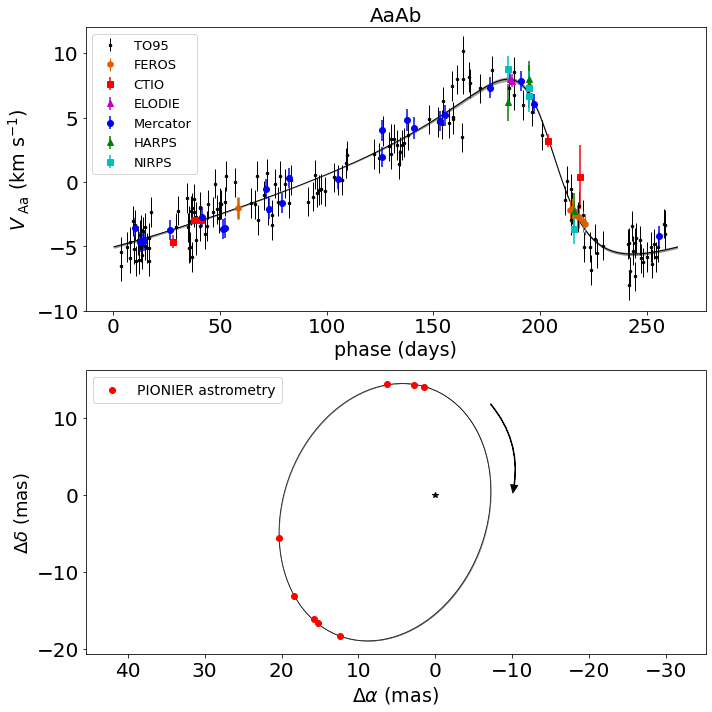

In [ ]:
import matplotlib.patches as patches

# calculate the errors for each instrument
TO95_err = np.sqrt(rva_err**2 + np.exp(2 * np.median(trace["logjitterTO95"])))
ELODIE_err = np.sqrt(rva_err_ELODIE**2 + np.exp(2 * np.median(trace["logjitterELODIE"])))
Mercator_err = np.sqrt(rva_err_Mercator**2 + np.exp(2 * np.median(trace["logjitterMercator"])))
CTIO_err = np.sqrt(rva_err_CTIO**2 + np.exp(2 * np.median(trace["logjitterCTIO"])))
FEROS_err = np.sqrt(rva_err_FEROS**2 + np.exp(2 * np.median(trace["logjitterFEROS"])))
FEROS_err2 = np.sqrt(rva_err_FEROS2**2 + np.exp(2 * np.median(trace["logjitterFEROS2"])))
HARPS_err = np.sqrt(rva_err_HARPS**2 + np.exp(2 * np.median(trace["logjitterHARPS_A"])))
NIRPS_err = np.sqrt(rva_err_NIRPS**2 + np.exp(2 * np.median(trace["logjitterNIRPS_A"])))

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

period = np.percentile(trace["P"], [16, 50, 84], axis=0)
gamma = np.percentile(trace["gamma"], [16, 50, 84], axis = 0)
gamma_FEROS = np.percentile(trace["gamma_FEROS"], [16, 50, 84], axis = 0)
gamma_FEROS2 = np.percentile(trace["gamma_FEROS2"], [16, 50, 84], axis = 0)
gamma_CTIO = np.percentile(trace["gamma_CTIO"], [16, 50, 84], axis = 0)
gamma_ELODIE = np.percentile(trace["gamma_ELODIE"], [16, 50, 84], axis = 0)
gamma_Mercator = np.percentile(trace["gamma_Mercator"], [16, 50, 84], axis = 0)
gamma_HARPS = np.percentile(trace["gamma_HARPS"], [16, 50, 84], axis = 0)
gamma_NIRPS = np.percentile(trace["gamma_NIRPS"], [16, 50, 84], axis = 0)

ax = axes[1]

style = "Simple, tail_width=0.5, head_width=7, head_length=8"
kw = dict(arrowstyle=style, color="k")

a3 = patches.FancyArrowPatch((-7.0, 12), (-10.0, 0),
                             connectionstyle="arc3,rad=-.25", **kw)
plt.gca().add_patch(a3)

# Plot the folded model
x_fold = t_fine % period[1]
inds = np.argsort(x_fold)

x_model = trace["x_save"][:, inds]
y_model = trace["y_save"][:, inds]

qx = np.percentile(x_model, [16, 50, 84], axis=0)
qy = np.percentile(y_model, [16, 50, 84], axis=0)



ax.set_ylabel(r"$\Delta \delta$ (mas)", fontsize=18)
ax.scatter(x, y, marker='o', color='r', label='PIONIER astrometry', zorder=3)
ax.plot(qx[1]*1000, qy[1]*1000, color = "k", lw=0.7, zorder=2)

# 1-sgima orbit range
ax.fill_between(qx[0]*1000, qy[0]*1000, qy[2]*1000, color="k", lw=0.2, alpha = 0.4, zorder=1)
ax.fill_between(qx[2]*1000, qy[0]*1000, qy[2]*1000, color="k", lw=0.2, alpha = 0.4, zorder=1)

ax.legend(loc='upper left', prop={'size': 14})
ax.set_xlabel(r"$\Delta \alpha$ (mas)", fontsize=19)
ax.invert_xaxis()
ax.plot(0, 0, "k*")
ax.set_aspect("equal", "datalim")


ax = axes[0]


va_model = trace["va_save"][:, inds]
va_model = np.percentile(va_model, [16, 50, 84], axis=0)

ax.plot(x_fold[inds], va_model[1], color="k", lw=1)
ax.fill_between(x_fold[inds], va_model[0], va_model[2], color="k", lw=0.1, alpha = 0.4)
    
ax.errorbar(t % period[1], rva - gamma[1], yerr=TO95_err, fmt=".k", lw=1, label = "TO95", ms=5)
ax.errorbar(t_FEROS % period[1], rva_FEROS - gamma_FEROS[1], yerr=FEROS_err, fmt="h", color="#d95f02",
            lw=1, ms = 6, label="FEROS")
ax.errorbar(t_FEROS2 % period[1], rva_FEROS2 - gamma_FEROS2[1], yerr=FEROS_err2, fmt="h", color="#d95f02",
            lw=2.5, ms = 6)
ax.errorbar(t_CTIO % period[1], rva_CTIO - gamma_CTIO[1], yerr=CTIO_err, fmt="sr",
            lw=1.5, ms = 6, label="CTIO")
ax.errorbar(t_ELODIE % period[1], rva_ELODIE - gamma_ELODIE[1], yerr=ELODIE_err, fmt="^m",
            lw=1.5, ms = 6, label="ELODIE")
ax.errorbar(t_Mercator % period[1], rva_Mercator - gamma_Mercator[1], yerr=Mercator_err, fmt="ob",
            lw=1.5, ms = 6, label="Mercator")
ax.errorbar(t_HARPS % period[1], rva_HARPS - gamma_HARPS[1], yerr=HARPS_err, fmt="^g",
            lw=1.5, ms = 6, label="HARPS")
ax.errorbar(t_NIRPS % period[1], rva_NIRPS - gamma_NIRPS[1], yerr=NIRPS_err, fmt="sc",
            lw=1.5, ms = 6, label="NIRPS")

ax.set_title("AaAb", fontsize=20)
ax.legend(loc='upper left', prop={'size': 13})
ax.set_ylim(-10,12)
ax.set_ylabel("$V_{~\mathrm{Aa}}$ ($\mathrm{km~s^{-1}}$)", fontsize=19)
ax.set_xlabel("phase (days)", fontsize=19)

plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)

plt.tight_layout()

plt.savefig('Plots/AaAb_Orbit.png')


In [46]:
#print("O-C ELODIE A")
#print(np.percentile(trace["OC_ELOa"], [16, 50, 84], axis = 0)[1])
#print(ELO_errA)

#print("O-C FEROS")
#print(np.percentile(trace["OC_FEROSa"], [16, 50, 84], axis = 0)[1])
#print(FEROS_errA)

#print("O-C FEROS 2")
#print(np.percentile(trace["OC_FEROSa2"], [16, 50, 84], axis = 0)[1])
#print(FEROS_err2)

#print("O-C CTIO A")
#print(np.percentile(trace["OC_CTIOa"], [16, 50, 84], axis = 0)[1])
#print(CTIO_errA)

#print("")
#print("O-C astrometry")
#print(np.percentile(trace["Maj_err"], [16, 50, 84], axis = 0)[1])
#print(astro_sigma_maj)
#print("")
#print(np.percentile(trace["Min_err"], [16, 50, 84], axis = 0)[1])
#print(astro_sigma_min)

In [47]:
# Run the model again with the parallax from BaBb solution value to get the masses of Aa and Ab
model2, map_soln2 = get_model(parallax=plx_BaBb)

optimizing logp for variables: [logjitterNIRPS_A, logjitterHARPS_A, logjitterMercator, logjitterELODIE, logjitterCTIO, logjitterFEROS2, logjitterFEROS, logjitterTO95, gamma_NIRPS, gamma_HARPS, gamma_Mercator, gamma_ELODIE, gamma_CTIO, gamma_FEROS2, gamma_FEROS, gamma, M_2, m_plx, K1, cos_incl, tp, ecc, Omega, omega, logP]


message: Desired error not necessarily achieved due to precision loss.
logp: -294522.7840952996 -> -300.91855224828623


In [48]:
# Now we can run the MCMC sampler:
np.random.seed(39091)
with model2:
    trace = pmx.sample(
        tune=2500, draws=2000, start=map_soln2, chains=4, cores=4, target_accept=0.95, init="adapt_full",
    )

/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/pymc3_ext/sampling/sampling.py:109: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return pm.sample(draws=draws, tune=tune, model=model, step=step, **kwargs)
Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc3:Multiprocess sampling (4 chains in 4 jobs)
NUTS: [logjitterNIRPS_A, logjitterHARPS_A, logjitterMercator, logjitterELODIE, logjitterCTIO, logjitterFEROS2, logjitterFEROS, logjitterTO95, gamma_NIRPS, gamma_HARPS, gamma_Mercator, gamma_ELODIE, gamma_CTIO, gamma_FEROS2, gamma_FEROS, gamma, M_2, m_plx, K1, cos_incl, tp, ecc, Omega, omega, logP]
INFO:pymc3:NUTS: [logjitterNIRPS_A, logjitterHARPS_A, logjitterMercator, logjitterELODIE, logjitterCTIO, logjitterFEROS2, logjitterFEROS, logjitterTO95, gamma_NIRPS, gamma_HARPS, gamma_Me

/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/macspeculoos/opt/anaconda3/envs/exoplanet_env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 184 seconds.
INFO:pymc3:Sampling 4 chains for 2_500 tune and 2_000 draw iterations 

Period (days): 264.507$\pm$0.019
Tp (MJD): 48742.46$\pm$0.74
omega (deg): 68.704$\pm$0.098
Omega (deg): 170.17$\pm$0.15
i (deg): 135.59$\pm$0.12
a (mas): 19.036$\pm$0.015
e: 0.48081$\pm$0.00084
Pandas support in corner is deprecated; use ArviZ directly


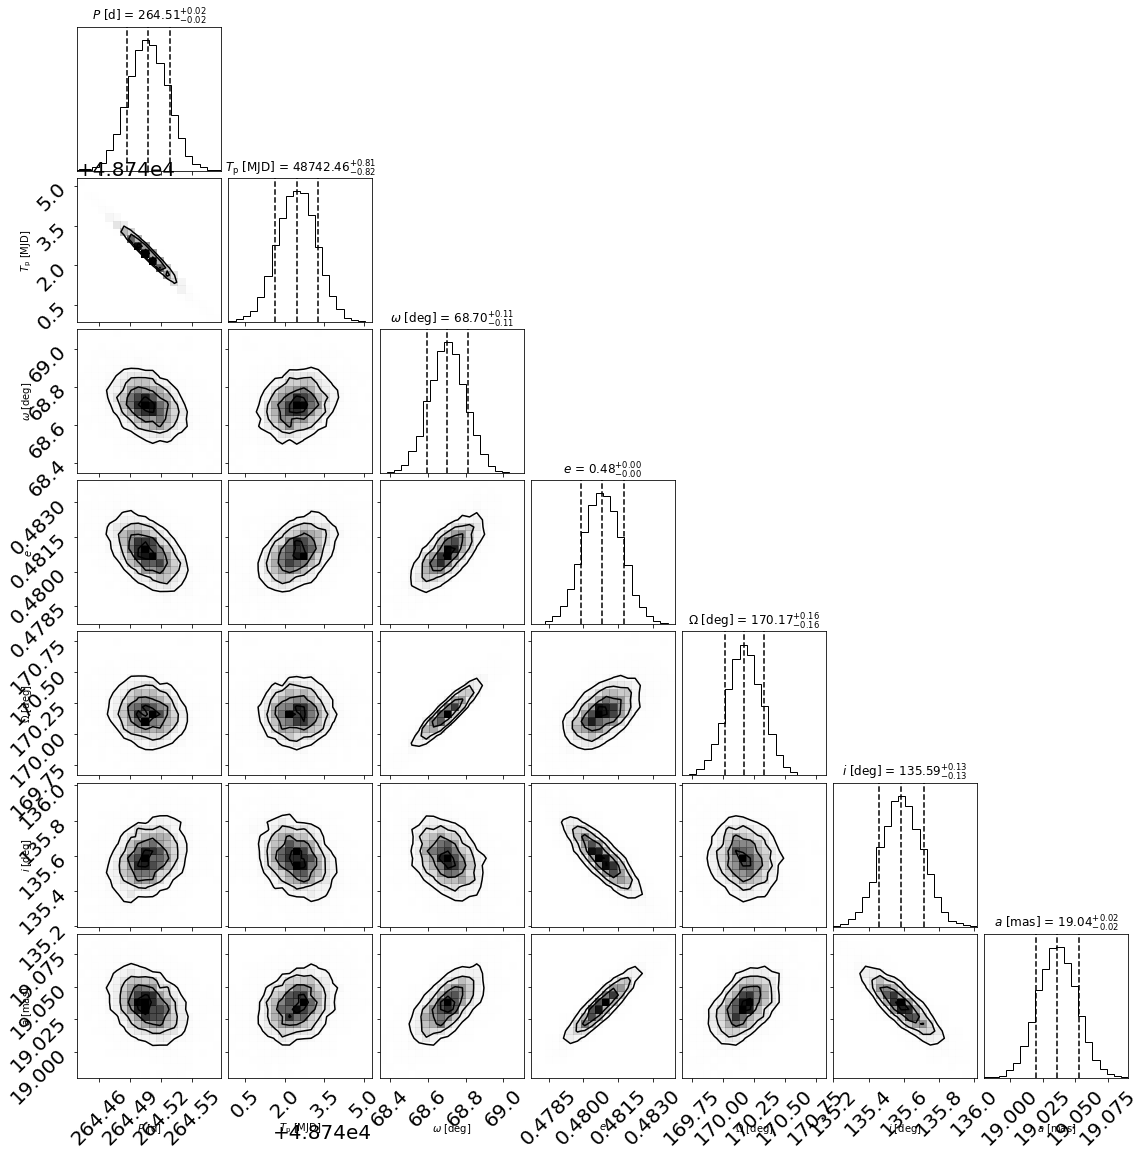

In [ ]:
# Check the new fitting results
samples = pm.trace_to_dataframe(trace, varnames=["Omega"])
samples["$P$ [d]"] = trace["P"]
samples["$T_\mathrm{p}$ [MJD]"] = trace["tp"] - 2400000.5
samples["$\omega$ [deg]"] = (trace["omega"] * rad_2_deg) % 360
samples["$e$"] = trace["ecc"]
samples["$\Omega$ [deg]"] = (trace["Omega"] / deg) % 360
samples["$i$ [deg]"] = (trace["incl"] / deg) % 180
samples["$a$ [mas]"] = trace["a_ang"] * 1000
#samples["M2 [$M_{\odot}$]"] = (trace["M_2"]) 
#samples["$K1$ [km/s]"] = (trace["K1"])
#samples["$\gamma_1$ [km/s]"] = (trace["gamma"])
#samples["$\gamma_2$ [km/s]"] = (trace["gamma_2"])

period, period_s = get_median_sigma(trace["P"])
print("Period (days): "+fmt(period, period_s))

tp, tp_s = get_median_sigma(trace["tp"]- 2400000.5)
print("Tp (MJD): "+fmt(tp, tp_s))

omega, omega_s = get_median_sigma((trace["omega"] * rad_2_deg) % 360)
print("omega (deg): "+fmt(omega, omega_s))

Omega, Omega_s = get_median_sigma((trace["Omega"] * rad_2_deg) % 360)
print("Omega (deg): "+fmt(Omega, Omega_s))

inc, inc_s = get_median_sigma((trace["incl"] * rad_2_deg) % 180)
print("i (deg): "+fmt(inc, inc_s))

aang, aang_s = get_median_sigma(trace["a_ang"]*1000)
print("a (mas): "+fmt(aang, aang_s))

ecc, ecc_s = get_median_sigma(trace["ecc"])
print("e: "+fmt(ecc, ecc_s))

#M_2, M_2_s = get_median_sigma(trace["M_2"])
#print("M2: "+fmt(M_2, M_2_s))

#gamma, gamma_s = get_median_sigma(trace["gamma"])
#print("gamma TO95 (km/s): "+fmt(gamma, gamma_s))

#gammaL, gammaL_s = get_median_sigma(trace["gamma_F"])
#print("gamma FEROS (km/s): "+fmt(gammaL, gammaL_s))

#gammaC, gammaC_s = get_median_sigma(trace["gamma_C"])
#print("gamma CTIO (km/s): "+fmt(gammaC, gammaC_s))

del samples["Omega"]
_ = corner.corner(samples,quantiles=[0.136, 0.5, 0.864], show_titles=True,
                  title_kwargs={"fontsize": 12}, plot_datapoints=False)


#plt.savefig('AaAb_corner.pdf')  




M1: 0.954$\pm$0.061
M2: 0.298$\pm$0.013
plx (mas): 21.90$\pm$0.40
a (AU): 0.869$\pm$0.016
Pandas support in corner is deprecated; use ArviZ directly


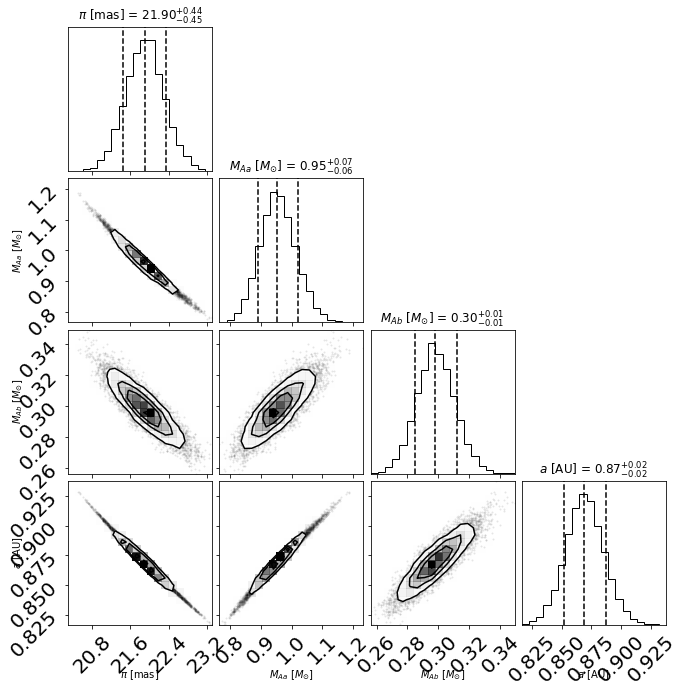

In [ ]:
# Lets check the estimated physical parameters

samples = pm.trace_to_dataframe(trace, varnames=["Omega"])
#samples["$P$ [d]"] = trace["P"]
#samples["$T_\mathrm{p}$ [MJD]"] = trace["tp"] - 2400000.5
#samples["$\omega$ [deg]"] = (trace["omega"] * rad_2_deg) % 360
#samples["$\Omega$ [deg]"] = (trace["Omega"] / deg) % 360
#samples["$M_{t}$"] = trace["MA"]
samples["$\pi$ [mas]"] = trace["m_plx"]
samples["$M_{Aa}$ [$M_{\odot}$]"] = (trace["M_t"] - trace["M_2"])
samples["$M_{Ab}$ [$M_{\odot}$]"] = (trace["M_2"]) 
#samples["$K2$ [km/s]"] = (trace["K_2"])
#samples["$K1$ [km/s]"] = (trace["K1"])
#samples["$\gamma_1$ [km/s]"] = (trace["gamma"])
#samples["$\gamma_2$ [km/s]"] = (trace["gamma_2"])
samples["$a$ [AU]"] = trace["a"]
#samples["$i$ [deg]"] = (trace["incl"] / deg) % 360




M1b, M1b_s = get_median_sigma(trace["M_t"] - trace["M_2"])
print("M1: "+fmt(M1b, M1b_s))

M2b, M2b_s = get_median_sigma(trace["M_2"])
print("M2: "+fmt(M2b, M2b_s))

plxb, plxb_s = get_median_sigma(trace["m_plx"])
print("plx (mas): "+fmt(plxb, plxb_s))

ah, ah_s = get_median_sigma(trace["a"])
print("a (AU): "+fmt(ah, ah_s))

del samples["Omega"]

samples.to_csv("CSV/AaAb_Mass_plx_posteriors.csv", index=False)

_ = corner.corner(samples,quantiles=[0.136, 0.5, 0.864], show_titles=True,
                  title_kwargs={"fontsize": 12})

#Save masses and plx for later comparison
samples_sol1 = samples[["$M_{Aa}$ [$M_{\odot}$]","$M_{Ab}$ [$M_{\odot}$]","$\pi$ [mas]"]]

plt.savefig('Plots/AaAb_corner_Mass_plx.pdf') 

In [51]:
with model2:
    txt, bib = xo.citations.get_citations_for_model()
    
print(bib)


@article{exoplanet:joss,
       author = {{Foreman-Mackey}, Daniel and {Luger}, Rodrigo and {Agol}, Eric
                and {Barclay}, Thomas and {Bouma}, Luke G. and {Brandt},
                Timothy D. and {Czekala}, Ian and {David}, Trevor J. and
                {Dong}, Jiayin and {Gilbert}, Emily A. and {Gordon}, Tyler A.
                and {Hedges}, Christina and {Hey}, Daniel R. and {Morris},
                Brett M. and {Price-Whelan}, Adrian M. and {Savel}, Arjun B.},
        title = "{exoplanet: Gradient-based probabilistic inference for
                  exoplanet data \& other astronomical time series}",
      journal = {arXiv e-prints},
         year = 2021,
        month = may,
          eid = {arXiv:2105.01994},
        pages = {arXiv:2105.01994},
archivePrefix = {arXiv},
       eprint = {2105.01994},
 primaryClass = {astro-ph.IM},
       adsurl = {https://ui.adsabs.harvard.edu/abs/2021arXiv210501994F},
      adsnote = {Provided by the SAO/NASA Astrophysics Data System

In [52]:
print(txt)

This research made use of \textsf{exoplanet} \citep{exoplanet:joss,
exoplanet:zenodo} and its dependencies \citep{exoplanet:arviz,
exoplanet:astropy13, exoplanet:astropy18, exoplanet:pymc3, exoplanet:theano}.


In [53]:

# ─────────────────────────────────────────────────────────────────────────────
# Monthly on-sky motion of Ab relative to Aa  (AaAb inner orbit)
# Uses the joint RV+astrometry posterior (model2, with BaBb parallax prior)
# x_save / y_save → Δα, Δδ in arcsec  (from orbit.get_relative_position)
# ─────────────────────────────────────────────────────────────────────────────

one_month   = 365.25 / 12               # ≈ 30.44 days
t_now_jd    = Time.now().jd
t_label     = Time.now().iso[:10]

# Re-build phase-sorted orbit from the current (model2) trace ─────────────────
P_med      = period                     # scalar median period [days]
phase_fine = t_fine % P_med             # phase (days) for each t_fine point
sort_idx   = np.argsort(phase_fine)
phases_srt = phase_fine[sort_idx]       # sorted: 0 → P_med

# Percentile positions (arcsec), sorted by phase
qx_s = np.percentile(trace["x_save"][:, sort_idx], [16, 50, 84], axis=0)
qy_s = np.percentile(trace["y_save"][:, sort_idx], [16, 50, 84], axis=0)

# Phases for today and one month later (same modulo convention) ───────────────
phase_now   =  t_now_jd              % P_med
phase_later = (t_now_jd + one_month) % P_med

# Interpolate position percentiles at both epochs (arcsec) ────────────────────
x_now   = np.array([np.interp(phase_now,   phases_srt, qx_s[i]) for i in range(3)])
y_now   = np.array([np.interp(phase_now,   phases_srt, qy_s[i]) for i in range(3)])
x_later = np.array([np.interp(phase_later, phases_srt, qx_s[i]) for i in range(3)])
y_later = np.array([np.interp(phase_later, phases_srt, qy_s[i]) for i in range(3)])

# Monthly displacement (arcsec → mas) ─────────────────────────────────────────
dx  = (x_later - x_now) * 1000         # Δ(Δα) [mas]
dy  = (y_later - y_now) * 1000         # Δ(Δδ) [mas]
dr  = np.sqrt(dx**2 + dy**2)           # total displacement [mas]

# Separation ρ and position angle θ at each epoch ─────────────────────────────
rho_now   = np.sqrt(x_now**2   + y_now**2)   * 1000   # [mas]
rho_later = np.sqrt(x_later**2 + y_later**2) * 1000   # [mas]
drho      = rho_later - rho_now                        # Δρ [mas]

theta_now   = np.degrees(np.arctan2(x_now[1],   y_now[1]))   % 360   # PA [deg]
theta_later = np.degrees(np.arctan2(x_later[1], y_later[1])) % 360
dtheta      = theta_later - theta_now
dtheta      = (dtheta + 180) % 360 - 180   # normalise to (−180, +180]

# Report ──────────────────────────────────────────────────────────────────────
print(f"On-sky motion of Ab relative to Aa over 1 month  [{t_label}]")
print(f"  Period  = {P_med:.2f} days  ({P_med/365.25:.3f} yr)")
print(f"  a_ang   = {aang:.1f} mas  (semi-major axis, 1-sigma: {aang_s:.1f} mas)")
print()
print(f"  Δ(Δα)  = {dx[1]:+.1f}  [{dx[0]:+.1f}, {dx[2]:+.1f}]  mas")
print(f"  Δ(Δδ)  = {dy[1]:+.1f}  [{dy[0]:+.1f}, {dy[2]:+.1f}]  mas")
print(f"  |Δpos|  = {dr[1]:.1f}  [{dr[0]:.1f}, {dr[2]:.1f}]  mas")
print(f"          = {dr[1]/1000:.4f} arcsec/month")
print()
print(f"  Δρ      = {drho[1]:+.1f}  [{drho[0]:+.1f}, {drho[2]:+.1f}]  mas")
print(f"  Δθ      = {dtheta:+.2f}  deg/month")
print()
print(f"  Mean speed (circular approx): {2*np.pi*aang/P_med*one_month:.1f} mas/month")


On-sky motion of Ab relative to Aa over 1 month  [2026-07-16]
  Period  = 264.51 days  (0.724 yr)
  a_ang   = 19.0 mas  (semi-major axis, 1-sigma: 0.0 mas)

  Δ(Δα)  = +6.5  [+6.5, +6.5]  mas
  Δ(Δδ)  = +3.4  [+3.4, +3.4]  mas
  |Δpos|  = 7.4  [7.4, 7.3]  mas
          = 0.0074 arcsec/month

  Δρ      = +1.3  [+1.3, +1.3]  mas
  Δθ      = -18.88  deg/month

  Mean speed (circular approx): 13.8 mas/month
